# Genre Classifier: Post-Download Pipeline (Full Run)

This notebook turns your completed `deemix` download manifest into a trainable dataset and runs the model pipeline.

Pipeline stages:
1. Validate downloaded files from the manifest
2. Build training-ready raw metadata (`artist/title/album/genre` schema)
3. Clean metadata and create artist-grouped train/val/test splits
4. Convert audio to standardized MP3
5. Extract handcrafted audio features (MFCC/chroma/spectral stats)
6. Extract CLAP audio embeddings
7. Train metadata/audio/fusion models
8. Evaluate on the test split


## Prerequisites

- Dependencies installed from `requirements.txt`
- `ffmpeg` available on your `PATH`
- Download manifest exists at `sampled_spotify_tracks_with_paths.csv`
- Downloaded files exist in `data/raw/deemix_downloads`

This notebook assumes your manifest includes these columns:
`track_id`, `artists`, `track_name`, `album_name`, `track_genre`, `download_filepath`.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import joblib

from src.data.clean_metadata import clean_metadata
from src.data.make_splits import make_splits
from src.data.convert_audio import batch_convert
from src.features.extract_handcrafted_audio import extract_handcrafted_features, merge_handcrafted_into_metadata
from src.data.prepare_extra_audio import prepare_extra_audio_dataset

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, log_loss

from src.models.evaluate import (
    load_embeddings,
    build_track_level_audio_eval_df,
    audio_probs_for_track_ids,
    _load_audio_preprocessor,
)
from src.models.train import get_metadata_X


## Configuration

Adjust these paths and knobs if needed. The defaults below match your current project layout.


In [50]:
PROJECT_ROOT = Path('.').resolve()

MANIFEST_CSV = PROJECT_ROOT / 'sampled_spotify_tracks_with_paths.csv'
DOWNLOAD_DIR = PROJECT_ROOT / 'data' / 'raw' / 'deemix_downloads'
EXTRA_AUDIO_DIR = PROJECT_ROOT / 'extra_audio'

RAW_METADATA_CSV = PROJECT_ROOT / 'data' / 'raw' / 'metadata' / 'deemix_raw.csv'
CLEAN_METADATA_CSV = PROJECT_ROOT / 'data' / 'processed' / 'metadata.csv'
SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits'
PROCESSED_AUDIO_DIR = PROJECT_ROOT / 'data' / 'processed' / 'audio'
EMBEDDINGS_NPZ = PROJECT_ROOT / 'data' / 'processed' / 'embeddings' / 'audio_embeddings_windows.npz'
HANDCRAFTED_FEATURES_CSV = PROJECT_ROOT / 'data' / 'processed' / 'features' / 'handcrafted_audio_features.csv'
EXTRA_METADATA_CSV = PROJECT_ROOT / 'data' / 'processed' / 'extra_audio_metadata.csv'
EXTRA_SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits' / 'extra_audio'
AUDIO_AUG_SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits' / 'audio_augmented'
AUDIO_AUG_METADATA_CSV = PROJECT_ROOT / 'data' / 'processed' / 'metadata_audio_augmented.csv'
MODEL_DIR = PROJECT_ROOT / 'models' / 'full_run'

# Optional curated dataset mode (from dataset_curation_pipeline.ipynb)
USE_CURATED_DATASET = True
CURATED_METADATA_CSV = PROJECT_ROOT / 'data' / 'processed' / 'metadata_curated.csv'
CURATED_SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits' / 'curated'

if USE_CURATED_DATASET:
    CLEAN_METADATA_CSV = CURATED_METADATA_CSV
    SPLITS_DIR = CURATED_SPLITS_DIR

SWEEP_DIR = MODEL_DIR / 'sweeps'

# Spectrogram CNN branch (optional)
RUN_SPECTROGRAM_CNN = True
RUN_DATA2_PRETRAIN = True
RUN_CNN_FINETUNE_MAIN = True
RUN_CNN_EVAL = True
RUN_CNN_FUSION = True

DATA2_ROOT = PROJECT_ROOT / 'Data 2' / 'genres_original'
DATA2_METADATA_CSV = PROJECT_ROOT / 'data' / 'processed' / 'data2_metadata.csv'
DATA2_SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits' / 'data2_spectrogram'
DATA2_SPECTROGRAM_DIR = PROJECT_ROOT / 'data' / 'processed' / 'spectrograms' / 'data2'
MAIN_SPECTROGRAM_DIR = PROJECT_ROOT / 'data' / 'processed' / 'spectrograms' / 'main'

CNN_PRETRAIN_DIR = MODEL_DIR / 'cnn_pretrain_data2'
CNN_MAIN_DIR = MODEL_DIR / 'cnn_main'

DATA2_TRAIN_RATIO = 0.70
DATA2_VAL_RATIO = 0.15

SPEC_SR = 22050
SPEC_SEGMENT_SEC = 3.0
SPEC_OVERLAP = 0.5
SPEC_N_MELS = 128
SPEC_N_FFT = 2048
SPEC_HOP_LENGTH = 512
SPEC_MAX_SEGMENTS_PER_TRACK = 0  # 0 disables cap
SPEC_WINDOW_SAMPLING = 'uniform'  # start|uniform|random
SPEC_WINDOW_SAMPLING_SEED = 42
SPEC_CACHE_DTYPE = 'float16'  # float16|float32

CNN_BATCH_SIZE = 32
CNN_EPOCHS = 120
CNN_LR = 1e-3
CNN_L2 = 1e-3
CNN_FREEZE_BACKBONE_EPOCHS = 8
CNN_NO_AUGMENT = False
CNN_USE_CLASS_WEIGHTS = False
CNN_USE_PRETRAIN_WEIGHTS = True

CNN_FUSION_GRID_STEPS = 21  # simplex grid resolution for meta+audio+cnn

# Quickstart profile for CNN branch
CNN_QUICKSTART_MODE = True
if CNN_QUICKSTART_MODE:
    RUN_SPECTROGRAM_CNN = True
    RUN_DATA2_PRETRAIN = CNN_USE_PRETRAIN_WEIGHTS
    RUN_CNN_FINETUNE_MAIN = True
    RUN_CNN_EVAL = True
    RUN_CNN_FUSION = True

    # Conservative defaults for first end-to-end run.
    SPEC_MAX_SEGMENTS_PER_TRACK = 2
    CNN_EPOCHS = 25
    CNN_FREEZE_BACKBONE_EPOCHS = 4
    CNN_FUSION_GRID_STEPS = 11



# Label-noise / class-imbalance controls
MIN_GENRE_COUNT = 120
MAX_GENRES = 10
DROP_GENRES = ['blues','reggae','country']  # e.g. ['spoken word']
MAX_SAMPLES_PER_GENRE = 800
CLEAN_SEED = 42

CONVERT_WORKERS = 8
EMBED_BATCH_SIZE = 16

# Default windowed CLAP embedding config
WINDOW_SEC = 3.0
WINDOWS_PER_TRACK = 8
WINDOW_SEED = 42

# Optional handcrafted audio features (DSP stats)
ENABLE_HANDCRAFTED_AUDIO_FEATURES = True
HF_SAMPLE_RATE = 22050
HF_MAX_DURATION_SEC = 120.0
HF_N_MFCC = 20
HF_N_FFT = 2048
HF_HOP_LENGTH = 512

# Optional extra folder-based audio dataset
USE_EXTRA_AUDIO = EXTRA_AUDIO_DIR.exists()
INCLUDE_EXTRA_IN_VAL = False
INCLUDE_EXTRA_IN_TEST = True
EXTRA_AUDIO_TRAIN_RATIO = 0.70
EXTRA_AUDIO_VAL_RATIO = 0.15
AUDIO_EXTRA_RATIO = 1.0  # target extra/base train-row ratio for audio model
AUDIO_RESAMPLE_SEED = 42
AUDIO_TRAIN_CSV = SPLITS_DIR / 'train.csv'
AUDIO_VAL_CSV = SPLITS_DIR / 'val.csv'
AUDIO_METADATA_FOR_EMBED = CLEAN_METADATA_CSV

# Classifier choices for late fusion
METADATA_CLASSIFIER = 'lightgbm'
AUDIO_CLASSIFIER = 'mlp'
FUSION_META_CLASSIFIER = METADATA_CLASSIFIER
FUSION_AUDIO_CLASSIFIER = AUDIO_CLASSIFIER
FUSION_WEIGHT_SEARCH_STEPS = 41

# Optional audio-only fusion (logreg + mlp, etc.)
RUN_AUDIO_FUSION = True
AUDIO_FUSION_CLASSIFIER_A = 'logreg'
AUDIO_FUSION_CLASSIFIER_B = 'mlp'
AUDIO_FUSION_WEIGHT_SEARCH_STEPS = 41

# Audio embedding preprocessing
AUDIO_L2_NORM = True
AUDIO_STANDARDIZE = 'auto'  # auto|on|off
AUDIO_PCA_COMPONENTS = 0.95  # 0 disables; (0,1)=variance ratio; >=1=fixed dim

# Default MLP hyperparameters
MLP_HIDDEN_LAYERS = '1024,512,256'
MLP_LR = 5e-4
MLP_ALPHA = 3e-4
MLP_BATCH_SIZE = 256
MLP_MAX_ITER = 500
MLP_PATIENCE = 25

# Optional sweep (can be expensive)
RUN_TUNING_SWEEP = False

# Probability-oriented analysis (Step 9)
PROB_ANALYSIS_SPLIT = 'test'  # test|val
PROB_ANALYSIS_MODE = 'audio_fusion' if RUN_AUDIO_FUSION else 'fusion'  # audio|fusion|audio_fusion
PROB_N_BINS = 10
PROB_N_EXAMPLES = 15
PROB_FUSION_WEIGHT_META_OVERRIDE = None  # None -> saved tuned weight or 0.5
PROB_AUDIO_FUSION_WEIGHT_A_OVERRIDE = None  # None -> saved tuned weight or 0.5

# Cluster visualization settings (Step 10, aligned with extra-audio notebook)
CLUSTER_LABELS_PURE = 6
CLUSTER_LABELS_AMBIG = 6
CLUSTER_POINT_ALPHA = 0.45
CLUSTER_RANDOM_STATE = 42
CLUSTER_LABEL_MIN_SEP = 0.055
CLUSTER_LABEL_FONT_SIZE = 8
CLUSTER_LABEL_MAX_LEN = 48
CLUSTER_DIVERSITY_BY_GENRE = True
CLUSTER_PURE_PER_GENRE = 1
CLUSTER_AMBIG_PER_GENRE = 1
CLUSTER_PALETTE = 'tab10'  # vivid categorical colors
CLUSTER_POINT_SIZE_MIN = 42
CLUSTER_POINT_SIZE_MAX = 130
CLUSTER_DENSITY_SIZE_BOOST = True
CLUSTER_DENSITY_K = 20
CLUSTER_CENTROID_SIZE = 320
CLUSTER_POINT_EDGE_WIDTH = 0.2
WINDOW_SEC_CANDIDATES = [6.0, 8.0, 10.0, 12.0]
WINDOWS_PER_TRACK_CANDIDATES = [4, 8, 12]
MLP_SWEEP = [
    {'hidden': '512,256', 'lr': 1e-3, 'alpha': 1e-4, 'max_iter': 300},
    {'hidden': '1024,512,256', 'lr': 5e-4, 'alpha': 3e-4, 'max_iter': 500},
    {'hidden': '256,128', 'lr': 1e-3, 'alpha': 1e-3, 'max_iter': 300},
]

for path in [RAW_METADATA_CSV.parent, CLEAN_METADATA_CSV.parent, SPLITS_DIR, PROCESSED_AUDIO_DIR, EMBEDDINGS_NPZ.parent, HANDCRAFTED_FEATURES_CSV.parent, EXTRA_METADATA_CSV.parent, EXTRA_SPLITS_DIR, AUDIO_AUG_SPLITS_DIR, AUDIO_AUG_METADATA_CSV.parent, MODEL_DIR, SWEEP_DIR, DATA2_METADATA_CSV.parent, DATA2_SPLITS_DIR, DATA2_SPECTROGRAM_DIR, MAIN_SPECTROGRAM_DIR, CNN_PRETRAIN_DIR, CNN_MAIN_DIR]:
    path.mkdir(parents=True, exist_ok=True)

{
    'manifest_exists': MANIFEST_CSV.exists(),
    'download_dir_exists': DOWNLOAD_DIR.exists(),
    'use_curated_dataset': USE_CURATED_DATASET,
    'curated_metadata_csv': str(CURATED_METADATA_CSV),
    'curated_metadata_exists': CURATED_METADATA_CSV.exists(),
    'curated_splits_dir': str(CURATED_SPLITS_DIR),
    'model_dir': str(MODEL_DIR),
    'embeddings_out': str(EMBEDDINGS_NPZ),
    'handcrafted_features_out': str(HANDCRAFTED_FEATURES_CSV),
    'use_extra_audio': USE_EXTRA_AUDIO,
    'extra_audio_dir': str(EXTRA_AUDIO_DIR),
    'audio_extra_ratio': AUDIO_EXTRA_RATIO,
    'audio_pca_components': AUDIO_PCA_COMPONENTS,
    'run_audio_fusion': RUN_AUDIO_FUSION,
    'audio_fusion_classifiers': (AUDIO_FUSION_CLASSIFIER_A, AUDIO_FUSION_CLASSIFIER_B),
    'run_tuning_sweep': RUN_TUNING_SWEEP,
    'run_spectrogram_cnn': RUN_SPECTROGRAM_CNN,
    'run_data2_pretrain': RUN_DATA2_PRETRAIN,
    'run_cnn_finetune_main': RUN_CNN_FINETUNE_MAIN,
    'run_cnn_eval': RUN_CNN_EVAL,
    'run_cnn_fusion': RUN_CNN_FUSION,
    'cnn_quickstart_mode': CNN_QUICKSTART_MODE,
    'prob_analysis': {
        'split': PROB_ANALYSIS_SPLIT,
        'mode': PROB_ANALYSIS_MODE,
        'bins': PROB_N_BINS,
        'examples': PROB_N_EXAMPLES,
    },
    'spectrogram_cnn': {
        'data2_root': str(DATA2_ROOT),
        'data2_root_exists': DATA2_ROOT.exists(),
        'data2_spectrogram_dir': str(DATA2_SPECTROGRAM_DIR),
        'main_spectrogram_dir': str(MAIN_SPECTROGRAM_DIR),
        'cnn_pretrain_dir': str(CNN_PRETRAIN_DIR),
        'cnn_main_dir': str(CNN_MAIN_DIR),
        'segment_sec': SPEC_SEGMENT_SEC,
        'overlap': SPEC_OVERLAP,
        'n_mels': SPEC_N_MELS,
        'window_sampling': SPEC_WINDOW_SAMPLING,
        'window_sampling_seed': SPEC_WINDOW_SAMPLING_SEED,
        'use_pretrained_weights': CNN_USE_PRETRAIN_WEIGHTS,
        'use_class_weights': CNN_USE_CLASS_WEIGHTS,
        'epochs': CNN_EPOCHS,
        'batch_size': CNN_BATCH_SIZE,
    },
    'cluster_viz': {
        'pure_labels': CLUSTER_LABELS_PURE,
        'ambiguous_labels': CLUSTER_LABELS_AMBIG,
        'label_min_sep': CLUSTER_LABEL_MIN_SEP,
        'label_font_size': CLUSTER_LABEL_FONT_SIZE,
        'label_max_len': CLUSTER_LABEL_MAX_LEN,
        'diversity_by_genre': CLUSTER_DIVERSITY_BY_GENRE,
        'pure_per_genre': CLUSTER_PURE_PER_GENRE,
        'ambiguous_per_genre': CLUSTER_AMBIG_PER_GENRE,
        'palette': CLUSTER_PALETTE,
        'point_size_min': CLUSTER_POINT_SIZE_MIN,
        'point_size_max': CLUSTER_POINT_SIZE_MAX,
        'density_size_boost': CLUSTER_DENSITY_SIZE_BOOST,
        'density_k': CLUSTER_DENSITY_K,
    },
}


{'manifest_exists': True,
 'download_dir_exists': True,
 'use_curated_dataset': True,
 'curated_metadata_csv': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/metadata_curated.csv',
 'curated_metadata_exists': True,
 'curated_splits_dir': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/curated',
 'model_dir': '/Volumes/MZ Music\uf028/genre-classifier/models/full_run',
 'embeddings_out': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz',
 'handcrafted_features_out': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/features/handcrafted_audio_features.csv',
 'use_extra_audio': True,
 'extra_audio_dir': '/Volumes/MZ Music\uf028/genre-classifier/extra_audio',
 'audio_extra_ratio': 1.0,
 'audio_pca_components': 0.95,
 'run_audio_fusion': True,
 'audio_fusion_classifiers': ('logreg', 'mlp'),
 'run_tuning_sweep': False,
 'run_spectrogram_cnn': True,
 'run_data2_pretrain': True,
 'run_cnn_finetune_main': True,
 'run_cnn_eval

## Preflight: Spectrogram CNN Checks

In [51]:
import importlib.util

def _exists(p: Path) -> bool:
    try:
        return Path(p).exists()
    except Exception:
        return False

tf_available = importlib.util.find_spec('tensorflow') is not None

preflight = {
    'tensorflow_installed': tf_available,
    'data2_root': str(DATA2_ROOT),
    'data2_root_exists': _exists(DATA2_ROOT),
    'curated_metadata_csv': str(CLEAN_METADATA_CSV),
    'curated_metadata_exists': _exists(CLEAN_METADATA_CSV),
    'splits_dir': str(SPLITS_DIR),
    'train_csv_exists': _exists(SPLITS_DIR / 'train.csv'),
    'val_csv_exists': _exists(SPLITS_DIR / 'val.csv'),
    'test_csv_exists': _exists(SPLITS_DIR / 'test.csv'),
    'processed_audio_dir': str(PROCESSED_AUDIO_DIR),
    'processed_audio_dir_exists': _exists(PROCESSED_AUDIO_DIR),
    'cnn_quickstart_mode': CNN_QUICKSTART_MODE,
    'run_spectrogram_cnn': RUN_SPECTROGRAM_CNN,
    'run_data2_pretrain': RUN_DATA2_PRETRAIN,
    'run_cnn_finetune_main': RUN_CNN_FINETUNE_MAIN,
    'run_cnn_eval': RUN_CNN_EVAL,
    'run_cnn_fusion': RUN_CNN_FUSION,
    'cnn_use_class_weights': CNN_USE_CLASS_WEIGHTS,
}

if RUN_SPECTROGRAM_CNN and not tf_available:
    print('WARNING: tensorflow is not installed in this environment; CNN cells will fail.')

if RUN_SPECTROGRAM_CNN and not _exists(DATA2_ROOT):
    print('WARNING: Data 2 root missing. Expected:', DATA2_ROOT)

preflight


{'tensorflow_installed': True,
 'data2_root': '/Volumes/MZ Music\uf028/genre-classifier/Data 2/genres_original',
 'data2_root_exists': True,
 'curated_metadata_csv': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/metadata_curated.csv',
 'curated_metadata_exists': True,
 'splits_dir': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/curated',
 'train_csv_exists': True,
 'val_csv_exists': True,
 'test_csv_exists': True,
 'processed_audio_dir': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/audio',
 'processed_audio_dir_exists': True,
 'cnn_quickstart_mode': True,
 'run_spectrogram_cnn': True,
 'run_data2_pretrain': True,
 'run_cnn_finetune_main': True,
 'run_cnn_eval': True,
 'run_cnn_fusion': True,
 'cnn_use_class_weights': False}

## Step 1: Inspect Download Manifest

This gives a quick quality check before building training metadata.


In [42]:
if USE_CURATED_DATASET:
    split_paths = {
        'train': SPLITS_DIR / 'train.csv',
        'val': SPLITS_DIR / 'val.csv',
        'test': SPLITS_DIR / 'test.csv',
    }
    summary = {
        'use_curated_dataset': True,
        'curated_metadata_csv': str(CLEAN_METADATA_CSV),
        'curated_metadata_exists': CLEAN_METADATA_CSV.exists(),
        'curated_split_paths': {k: str(v) for k, v in split_paths.items()},
        'curated_split_exists': {k: v.exists() for k, v in split_paths.items()},
    }
else:
    manifest = pd.read_csv(MANIFEST_CSV)

    # Normalize filepath field for checks
    manifest['download_filepath'] = manifest['download_filepath'].astype(str).str.strip()
    valid_fp_mask = (
        manifest['download_filepath'].ne('')
        & manifest['download_filepath'].str.lower().ne('nan')
        & manifest['download_filepath'].apply(lambda p: Path(p).exists())
    )

    summary = {
        'manifest_rows': len(manifest),
        'rows_with_existing_download_filepath': int(valid_fp_mask.sum()),
        'unique_track_ids': int(manifest['track_id'].nunique(dropna=True)),
    }

    if 'deemix_status' in manifest.columns:
        summary['status_counts'] = manifest['deemix_status'].value_counts(dropna=False).to_dict()

summary

{'use_curated_dataset': True,
 'curated_metadata_csv': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/metadata_curated.csv',
 'curated_metadata_exists': True,
 'curated_split_paths': {'train': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/curated/train.csv',
  'val': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/curated/val.csv',
  'test': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/curated/test.csv'},
 'curated_split_exists': {'train': True, 'val': True, 'test': True}}

## Step 2: Build Raw Metadata for Training

Actions performed:
- Keep only rows with an existing downloaded file
- Map source columns into the schema used by downstream scripts
- Drop track IDs that appear with conflicting genres
- Keep one row per `track_id`
- Save to `data/raw/metadata/deemix_raw.csv`

Why drop conflicting genres?
A single track appearing in multiple playlists with different labels creates contradictory supervision.


In [43]:
if USE_CURATED_DATASET:
    if not CLEAN_METADATA_CSV.exists():
        raise FileNotFoundError(
            f'Curated metadata not found: {CLEAN_METADATA_CSV}. '            'Run dataset_curation_pipeline.ipynb first or disable USE_CURATED_DATASET.'
        )

    out_df = pd.read_csv(CLEAN_METADATA_CSV)
    {
        'using_curated_dataset': True,
        'loaded_curated_csv': str(CLEAN_METADATA_CSV),
        'rows_loaded': len(out_df),
        'genres': out_df['genre'].value_counts().to_dict() if 'genre' in out_df.columns else {},
    }
else:
    base = manifest[valid_fp_mask].copy()

    base['artist'] = base['artists'].astype(str).str.split(';').str[0].str.strip()
    base['title'] = base['track_name'].astype(str).str.strip()
    base['album'] = base['album_name'].astype(str).str.strip()
    base['genre'] = base['track_genre'].astype(str).str.strip().str.lower()

    # Track IDs that have more than one genre assignment
    genre_count_per_tid = base.groupby('track_id')['genre'].nunique(dropna=True)
    ambiguous_track_ids = set(genre_count_per_tid[genre_count_per_tid > 1].index)

    dataset = base[~base['track_id'].isin(ambiguous_track_ids)].copy()
    dataset = dataset.drop_duplicates(subset=['track_id']).copy()

    feature_cols = [
        'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
        'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
        'time_signature', 'duration_ms', 'popularity', 'release_year'
    ]

    ordered_cols = ['track_id', 'artist', 'title', 'album', 'genre'] + [c for c in feature_cols if c in dataset.columns]
    out_df = dataset[ordered_cols].reset_index(drop=True)
    out_df.to_csv(RAW_METADATA_CSV, index=False)

    {
        'saved_to': str(RAW_METADATA_CSV),
        'rows_saved': len(out_df),
        'dropped_ambiguous_track_ids': len(ambiguous_track_ids),
        'genres': out_df['genre'].value_counts().to_dict(),
    }

## Step 3: Clean Metadata and Create Splits

- `clean_metadata` normalizes labels and text fields, drops rare genres, and removes duplicates.
- `make_splits` creates artist-grouped train/val/test splits to reduce artist leakage.


In [44]:
if USE_CURATED_DATASET:
    if not CLEAN_METADATA_CSV.exists():
        raise FileNotFoundError(
            f'Curated metadata not found: {CLEAN_METADATA_CSV}. '            'Run dataset_curation_pipeline.ipynb first or disable USE_CURATED_DATASET.'
        )

    clean_df = pd.read_csv(CLEAN_METADATA_CSV)

    train_csv = SPLITS_DIR / 'train.csv'
    val_csv = SPLITS_DIR / 'val.csv'
    test_csv = SPLITS_DIR / 'test.csv'

    if train_csv.exists() and val_csv.exists() and test_csv.exists():
        train_df = pd.read_csv(train_csv)
        val_df = pd.read_csv(val_csv)
        test_df = pd.read_csv(test_csv)
        split_source = 'existing_curated_splits'
    else:
        train_df, val_df, test_df = make_splits(
            metadata_csv=str(CLEAN_METADATA_CSV),
            out_dir=str(SPLITS_DIR),
            train_ratio=0.70,
            val_ratio=0.15,
            seed=CLEAN_SEED,
        )
        split_source = 'newly_generated_from_curated_metadata'

    {
        'use_curated_dataset': True,
        'split_source': split_source,
        'clean_rows': len(clean_df),
        'train_rows': len(train_df),
        'val_rows': len(val_df),
        'test_rows': len(test_df),
        'genres_after_cleaning': clean_df['genre'].value_counts().to_dict(),
    }
else:
    clean_df = clean_metadata(
        in_csv=str(RAW_METADATA_CSV),
        out_csv=str(CLEAN_METADATA_CSV),
        min_genre_count=MIN_GENRE_COUNT,
        max_genres=MAX_GENRES if MAX_GENRES > 0 else None,
        drop_genres=DROP_GENRES,
        max_samples_per_genre=(MAX_SAMPLES_PER_GENRE if MAX_SAMPLES_PER_GENRE > 0 else None),
        seed=CLEAN_SEED,
    )

    train_df, val_df, test_df = make_splits(
        metadata_csv=str(CLEAN_METADATA_CSV),
        out_dir=str(SPLITS_DIR),
        train_ratio=0.70,
        val_ratio=0.15,
        seed=42,
    )

    {
        'use_curated_dataset': False,
        'clean_rows': len(clean_df),
        'train_rows': len(train_df),
        'val_rows': len(val_df),
        'test_rows': len(test_df),
        'genres_after_cleaning': clean_df['genre'].value_counts().to_dict(),
    }

## Step 4: Convert Audio to Standardized MP3

This step ensures consistent audio format for embedding extraction.

Input: `data/raw/deemix_downloads/<track_id>.mp3`
Output: `data/processed/audio/<track_id>.mp3`


In [7]:
convert_status = batch_convert(
    metadata_csv=str(CLEAN_METADATA_CSV),
    in_audio_dir=str(DOWNLOAD_DIR),
    out_audio_dir=str(PROCESSED_AUDIO_DIR),
    bitrate=192,
    mono=False,
    workers=CONVERT_WORKERS,
)

convert_status['status'].value_counts(dropna=False).to_dict()


Converted 2253/2394 tracks  |  missing=141  |  failed=0


{'ok': 2253, 'missing_source': 141}

### Step 4b: Prepare Extra Audio Dataset (Optional)

If `extra_audio/` exists, this step:
- scans `<genre>/audio_file` folders
- converts files into `data/processed/audio/<track_id>.mp3`
- builds extra metadata/splits
- creates audio-augmented train/val splits with `source=base|extra`

Metadata/fusion still use the original base splits by default.


In [45]:
if USE_EXTRA_AUDIO:
    extra_summary = prepare_extra_audio_dataset(
        extra_audio_dir=str(EXTRA_AUDIO_DIR),
        processed_audio_dir=str(PROCESSED_AUDIO_DIR),
        out_metadata_csv=str(EXTRA_METADATA_CSV),
        out_extra_splits_dir=str(EXTRA_SPLITS_DIR),
        base_metadata_csv=str(CLEAN_METADATA_CSV),
        base_splits_dir=str(SPLITS_DIR),
        out_audio_splits_dir=str(AUDIO_AUG_SPLITS_DIR),
        out_audio_metadata_csv=str(AUDIO_AUG_METADATA_CSV),
        include_extra_val=INCLUDE_EXTRA_IN_VAL,
        include_extra_test=INCLUDE_EXTRA_IN_TEST,
        train_ratio=EXTRA_AUDIO_TRAIN_RATIO,
        val_ratio=EXTRA_AUDIO_VAL_RATIO,
        seed=CLEAN_SEED,
        bitrate=192,
        mono=False,
        sample_rate=22050,
        workers=CONVERT_WORKERS,
    )

    AUDIO_TRAIN_CSV = AUDIO_AUG_SPLITS_DIR / 'train.csv'
    AUDIO_VAL_CSV = AUDIO_AUG_SPLITS_DIR / 'val.csv'
    AUDIO_METADATA_FOR_EMBED = AUDIO_AUG_METADATA_CSV

    {
        'use_extra_audio': True,
        'audio_train_csv': str(AUDIO_TRAIN_CSV),
        'audio_val_csv': str(AUDIO_VAL_CSV),
        'audio_metadata_for_embed': str(AUDIO_METADATA_FOR_EMBED),
        'audio_extra_ratio': AUDIO_EXTRA_RATIO,
        'extra_summary': extra_summary,
    }
else:
    AUDIO_TRAIN_CSV = SPLITS_DIR / 'train.csv'
    AUDIO_VAL_CSV = SPLITS_DIR / 'val.csv'
    AUDIO_METADATA_FOR_EMBED = CLEAN_METADATA_CSV
    {
        'use_extra_audio': False,
        'audio_train_csv': str(AUDIO_TRAIN_CSV),
        'audio_val_csv': str(AUDIO_VAL_CSV),
        'audio_metadata_for_embed': str(AUDIO_METADATA_FOR_EMBED),
    }


train:   214 tracks (65.2%)  |  157 artists  |  8 genres
  val:    49 tracks (14.9%)  |  32 artists  |  8 genres
 test:    65 tracks (19.8%)  |  43 artists  |  8 genres
{
  "audio_combined_metadata": {
    "rows": 2722,
    "source_counts": {
      "base": 2394,
      "extra": 328
    }
  },
  "audio_combined_splits": {
    "test": {
      "rows": 347,
      "source_counts": {
        "base": 347
      }
    },
    "train": {
      "rows": 1944,
      "source_counts": {
        "base": 1730,
        "extra": 214
      }
    },
    "val": {
      "rows": 317,
      "source_counts": {
        "base": 317
      }
    }
  },
  "audio_metadata_csv": "/Volumes/MZ Music\uf028/genre-classifier/data/processed/metadata_audio_augmented.csv",
  "conversion_status": {
    "failed": 1,
    "ok": 328
  },
  "dropped_genres_filter": {},
  "extra_genres": {
    "classical": 17,
    "electronic": 46,
    "folk": 33,
    "indie": 42,
    "jazz": 49,
    "metal": 39,
    "pop": 52,
    "rock": 50
  },
  "

## Step 5: Extract Handcrafted Audio Features

This computes MFCC, chroma, spectral centroid, spectral rolloff, and zero-crossing-rate statistics
from each converted track and merges them into metadata + split CSVs.

Why this helps:
- adds timbral/harmonic cues complementary to CLAP embeddings
- gives the metadata model additional audio-informed signals
- can improve macro F1 on confusable genres


In [52]:
if ENABLE_HANDCRAFTED_AUDIO_FEATURES:
    handcrafted_df = extract_handcrafted_features(
        metadata_csv=str(CLEAN_METADATA_CSV),
        audio_dir=str(PROCESSED_AUDIO_DIR),
        out_csv=str(HANDCRAFTED_FEATURES_CSV),
        sample_rate=HF_SAMPLE_RATE,
        max_duration_sec=HF_MAX_DURATION_SEC,
        n_mfcc=HF_N_MFCC,
        n_fft=HF_N_FFT,
        hop_length=HF_HOP_LENGTH,
        resume=True,
    )

    target_csvs = [
        CLEAN_METADATA_CSV,
        SPLITS_DIR / 'train.csv',
        SPLITS_DIR / 'val.csv',
        SPLITS_DIR / 'test.csv',
    ]

    handcrafted_prefixes = (
        'mfcc_',
        'chroma_',
        'spectral_centroid_',
        'spectral_rolloff_',
        'zero_crossing_rate_',
    )

    merge_summary = {}
    for csv_path in target_csvs:
        merged_df = merge_handcrafted_into_metadata(
            metadata_csv=str(csv_path),
            features_csv=str(HANDCRAFTED_FEATURES_CSV),
            out_csv=str(csv_path),
        )
        handcrafted_cols = [
            c
            for c in merged_df.columns
            if any(c.startswith(prefix) for prefix in handcrafted_prefixes)
        ]
        matched = int(merged_df[handcrafted_cols[0]].notna().sum()) if handcrafted_cols else 0
        merge_summary[csv_path.name] = {
            'rows': len(merged_df),
            'handcrafted_feature_cols': len(handcrafted_cols),
            'tracks_with_handcrafted_features': matched,
        }

    {
        'handcrafted_features_csv': str(HANDCRAFTED_FEATURES_CSV),
        'feature_rows': len(handcrafted_df),
        'feature_columns': len(handcrafted_df.columns) - 1 if 'track_id' in handcrafted_df.columns else len(handcrafted_df.columns),
        'merge_summary': merge_summary,
    }
else:
    print('ENABLE_HANDCRAFTED_AUDIO_FEATURES=False -> skipping handcrafted feature extraction.')


Resuming handcrafted extraction: 2253 track_ids already saved


Extracting handcrafted: 100%|██████████| 2394/2394 [00:00<00:00, 30513.11it/s]

Saved handcrafted features -> /Volumes/MZ Music/genre-classifier/data/processed/features/handcrafted_audio_features.csv (rows=2253, new=0, missing_audio=141, failed=0, skipped_done=2253)


Merged handcrafted features into /Volumes/MZ Music/genre-classifier/data/processed/metadata_curated.csv (rows=2394, matched=2253)
Merged handcrafted features into /Volumes/MZ Music/genre-classifier/data/splits/curated/train.csv (rows=1730, matched=1621)
Merged handcrafted features into /Volumes/MZ Music/genre-classifier/data/splits/curated/val.csv (rows=317, matched=306)
Merged handcrafted features into /Volumes/MZ Music/genre-classifier/data/splits/curated/test.csv (rows=347, matched=326)


## Step 6: Extract Windowed Audio Embeddings (CLAP)

This creates multiple embeddings per track using random windows (data augmentation).

Output: `data/processed/embeddings/audio_embeddings_windows.npz`

NPZ keys: `track_ids`, `sample_ids`, `embeddings`

If `RUN_TUNING_SWEEP=True`, additional embeddings files are generated in the sweep loop.


In [53]:
from src.features.extract_audio import extract_embeddings

extract_embeddings(
    metadata_csv=str(AUDIO_METADATA_FOR_EMBED),
    audio_dir=str(PROCESSED_AUDIO_DIR),
    out_file=str(EMBEDDINGS_NPZ),
    batch_size=EMBED_BATCH_SIZE,
    window_sec=WINDOW_SEC,
    windows_per_track=WINDOWS_PER_TRACK,
    window_seed=WINDOW_SEED,
)


Resuming: 24568 embeddings already saved
Nothing to do (missing_audio=141)


## Step 7: Train Models

This section trains:
- metadata model (`lightgbm`)
- audio model (`mlp`) with embedding normalization + optional PCA dimensionality reduction
- weighted late-fusion model (metadata + audio probabilities; fusion weight tuned on val)

Optional: run a sweep across window sizes and MLP settings to pick the best validation fusion F1.


In [54]:
def run_cmd(cmd: list[str]) -> str:
    print('$', ' '.join(cmd))
    completed = subprocess.run(cmd, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.returncode != 0:
        if completed.stderr:
            print(completed.stderr)
        raise RuntimeError(f'Command failed with code {completed.returncode}')
    return completed.stdout or ''

python_bin = sys.executable


### Step 7a: Prepare Data 2 Spectrogram Dataset (Optional)

In [55]:
if RUN_SPECTROGRAM_CNN and RUN_DATA2_PRETRAIN:
    if not DATA2_ROOT.exists():
        raise FileNotFoundError(
            f'Data 2 root not found: {DATA2_ROOT}. '            'Expected something like "Data 2/genres_original".'
        )

    run_cmd([
        python_bin, '-m', 'src.data.prepare_data2_spectrogram',
        '--data_root', str(DATA2_ROOT),
        '--out_metadata_csv', str(DATA2_METADATA_CSV),
        '--out_splits_dir', str(DATA2_SPLITS_DIR),
        '--train_ratio', str(DATA2_TRAIN_RATIO),
        '--val_ratio', str(DATA2_VAL_RATIO),
        '--seed', str(CLEAN_SEED),
        '--report_json', str(DATA2_METADATA_CSV.parent / 'data2_prepare_report.json'),
    ])

    run_cmd([
        python_bin, '-m', 'src.features.extract_spectrogram',
        '--splits_dir', str(DATA2_SPLITS_DIR),
        '--out_dir', str(DATA2_SPECTROGRAM_DIR),
        '--sr', str(SPEC_SR),
        '--segment_sec', str(SPEC_SEGMENT_SEC),
        '--overlap', str(SPEC_OVERLAP),
        '--n_mels', str(SPEC_N_MELS),
        '--n_fft', str(SPEC_N_FFT),
        '--hop_length', str(SPEC_HOP_LENGTH),
        '--max_segments_per_track', str(SPEC_MAX_SEGMENTS_PER_TRACK),
        '--sampling', SPEC_WINDOW_SAMPLING,
        '--seed', str(SPEC_WINDOW_SAMPLING_SEED),
        '--out_dtype', SPEC_CACHE_DTYPE,
        '--report_json', str(DATA2_SPECTROGRAM_DIR / 'extract_report.json'),
    ])
else:
    print('RUN_SPECTROGRAM_CNN=False or RUN_DATA2_PRETRAIN=False -> skipping Data 2 prep.')


$ /opt/anaconda3/bin/python -m src.data.prepare_data2_spectrogram --data_root /Volumes/MZ Music/genre-classifier/Data 2/genres_original --out_metadata_csv /Volumes/MZ Music/genre-classifier/data/processed/data2_metadata.csv --out_splits_dir /Volumes/MZ Music/genre-classifier/data/splits/data2_spectrogram --train_ratio 0.7 --val_ratio 0.15 --seed 42 --report_json /Volumes/MZ Music/genre-classifier/data/processed/data2_prepare_report.json
{
  "data_root": "/Volumes/MZ Music\uf028/genre-classifier/Data 2/genres_original",
  "genres_total": 10,
  "out_metadata_csv": "/Volumes/MZ Music\uf028/genre-classifier/data/processed/data2_metadata.csv",
  "out_splits_dir": "/Volumes/MZ Music\uf028/genre-classifier/data/splits/data2_spectrogram",
  "rows_total": 1000,
  "source_label": "data2",
  "test": {
    "genres": {
      "blues": 15,
      "classical": 15,
      "country": 15,
      "disco": 15,
      "hiphop": 15,
      "jazz": 15,
      "metal": 16,
      "pop": 15,
      "reggae": 15,
  

### Step 7a.1: Prepare Main-Dataset Spectrogram Cache (Optional)

In [56]:
if RUN_SPECTROGRAM_CNN:
    run_cmd([
        python_bin, '-m', 'src.features.extract_spectrogram',
        '--splits_dir', str(SPLITS_DIR),
        '--out_dir', str(MAIN_SPECTROGRAM_DIR),
        '--audio_dir', str(PROCESSED_AUDIO_DIR),
        '--sr', str(SPEC_SR),
        '--segment_sec', str(SPEC_SEGMENT_SEC),
        '--overlap', str(SPEC_OVERLAP),
        '--n_mels', str(SPEC_N_MELS),
        '--n_fft', str(SPEC_N_FFT),
        '--hop_length', str(SPEC_HOP_LENGTH),
        '--max_segments_per_track', str(SPEC_MAX_SEGMENTS_PER_TRACK),
        '--sampling', SPEC_WINDOW_SAMPLING,
        '--seed', str(SPEC_WINDOW_SAMPLING_SEED),
        '--out_dtype', SPEC_CACHE_DTYPE,
        '--report_json', str(MAIN_SPECTROGRAM_DIR / 'extract_report.json'),
    ])
else:
    print('RUN_SPECTROGRAM_CNN=False -> skipping main spectrogram cache extraction.')


$ /opt/anaconda3/bin/python -m src.features.extract_spectrogram --splits_dir /Volumes/MZ Music/genre-classifier/data/splits/curated --out_dir /Volumes/MZ Music/genre-classifier/data/processed/spectrograms/main --audio_dir /Volumes/MZ Music/genre-classifier/data/processed/audio --sr 22050 --segment_sec 3.0 --overlap 0.5 --n_mels 128 --n_fft 2048 --hop_length 512 --max_segments_per_track 2 --sampling uniform --seed 42 --out_dtype float16 --report_json /Volumes/MZ Music/genre-classifier/data/processed/spectrograms/main/extract_report.json
{
  "class_names": [
    "classical",
    "electronic",
    "folk",
    "indie",
    "jazz",
    "metal",
    "pop",
    "rock"
  ],
  "config": {
    "audio_dir": "/Volumes/MZ Music\uf028/genre-classifier/data/processed/audio",
    "hop_length": 512,
    "max_segments_per_track": 2,
    "n_fft": 2048,
    "n_mels": 128,
    "out_dtype": "float16",
    "overlap": 0.5,
    "sampling": "uniform",
    "seed": 42,
    "segment_sec": 3.0,
    "splits_dir"

In [14]:
run_cmd([
    python_bin, '-m', 'src.models.train',
    '--modality', 'metadata',
    '--classifier', METADATA_CLASSIFIER,
    '--train_csv', str(SPLITS_DIR / 'train.csv'),
    '--val_csv', str(SPLITS_DIR / 'val.csv'),
    '--out_dir', str(MODEL_DIR),
])


$ /opt/anaconda3/bin/python -m src.models.train --modality metadata --classifier lightgbm --train_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/train.csv --val_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/val.csv --out_dir /Volumes/MZ Music/genre-classifier/models/full_run
Classes (8): ['classical', 'electronic', 'folk', 'indie', 'jazz', 'metal', 'pop', 'rock']
Metadata model: 84 features (70 handcrafted) | 8 classes | 1730 train / 317 val tracks
  val macro F1: 0.5801
Saved -> /Volumes/MZ Music/genre-classifier/models/full_run/metadata_lightgbm.joblib



"Classes (8): ['classical', 'electronic', 'folk', 'indie', 'jazz', 'metal', 'pop', 'rock']\nMetadata model: 84 features (70 handcrafted) | 8 classes | 1730 train / 317 val tracks\n  val macro F1: 0.5801\nSaved -> /Volumes/MZ Music\uf028/genre-classifier/models/full_run/metadata_lightgbm.joblib\n"

In [15]:
from src.features.extract_audio import extract_embeddings

import itertools
import re

def parse_macro_f1(text: str) -> float:
    m = re.search(r'test macro F1:\s*([0-9]*\.?[0-9]+)', text)
    if not m:
        raise RuntimeError('Could not parse macro F1 from output')
    return float(m.group(1))

def l2_flag() -> str:
    return '--audio_l2_norm' if AUDIO_L2_NORM else '--no_audio_l2_norm'

SELECTED_EMBEDDINGS_NPZ = EMBEDDINGS_NPZ
SELECTED_WINDOW_SEC = WINDOW_SEC
SELECTED_WINDOWS_PER_TRACK = WINDOWS_PER_TRACK
SELECTED_MLP_HIDDEN_LAYERS = MLP_HIDDEN_LAYERS
SELECTED_MLP_LR = MLP_LR
SELECTED_MLP_ALPHA = MLP_ALPHA
SELECTED_MLP_MAX_ITER = MLP_MAX_ITER

sweep_rows = []

if RUN_TUNING_SWEEP:
    for ws, wp, mlp_cfg in itertools.product(WINDOW_SEC_CANDIDATES, WINDOWS_PER_TRACK_CANDIDATES, MLP_SWEEP):
        embed_path = EMBEDDINGS_NPZ.parent / f'audio_embeddings_ws{int(ws)}_wp{int(wp)}.npz'

        extract_embeddings(
            metadata_csv=str(AUDIO_METADATA_FOR_EMBED),
            audio_dir=str(PROCESSED_AUDIO_DIR),
            out_file=str(embed_path),
            batch_size=EMBED_BATCH_SIZE,
            window_sec=float(ws),
            windows_per_track=int(wp),
            window_seed=WINDOW_SEED,
        )

        tag = f"ws{int(ws)}_wp{int(wp)}_h{mlp_cfg['hidden'].replace(',', '-')}_lr{mlp_cfg['lr']}"
        trial_dir = SWEEP_DIR / tag
        trial_dir.mkdir(parents=True, exist_ok=True)

        run_cmd([
            python_bin, '-m', 'src.models.train',
            '--modality', 'metadata',
            '--classifier', METADATA_CLASSIFIER,
            '--train_csv', str(SPLITS_DIR / 'train.csv'),
            '--val_csv', str(SPLITS_DIR / 'val.csv'),
            '--out_dir', str(trial_dir),
        ])

        run_cmd([
            python_bin, '-m', 'src.models.train',
            '--modality', 'audio',
            '--classifier', AUDIO_CLASSIFIER,
            '--train_csv', str(AUDIO_TRAIN_CSV),
            '--val_csv', str(AUDIO_VAL_CSV),
            '--embeddings', str(embed_path),
            '--audio_standardize', AUDIO_STANDARDIZE,
            '--audio_pca_components', str(AUDIO_PCA_COMPONENTS),
            l2_flag(),
            '--mlp_hidden_layers', mlp_cfg['hidden'],
            '--mlp_lr', str(mlp_cfg['lr']),
            '--mlp_alpha', str(mlp_cfg['alpha']),
            '--mlp_batch_size', str(MLP_BATCH_SIZE),
            '--mlp_max_iter', str(mlp_cfg['max_iter']),
            '--mlp_patience', str(MLP_PATIENCE),
            '--audio_source_col', 'source',
            '--audio_source_default_label', 'base',
            '--audio_source_extra_label', 'extra',
            '--audio_resample_extra_ratio', str(AUDIO_EXTRA_RATIO),
            '--audio_resample_seed', str(AUDIO_RESAMPLE_SEED),
            '--out_dir', str(trial_dir),
        ])

        run_cmd([
            python_bin, '-m', 'src.models.train',
            '--modality', 'fusion',
            '--val_csv', str(SPLITS_DIR / 'val.csv'),
            '--embeddings', str(embed_path),
            '--fusion_meta_classifier', FUSION_META_CLASSIFIER,
            '--fusion_audio_classifier', FUSION_AUDIO_CLASSIFIER,
            '--fusion_weight_search_steps', str(FUSION_WEIGHT_SEARCH_STEPS),
            '--out_dir', str(trial_dir),
        ])

        eval_out = run_cmd([
            python_bin, '-m', 'src.models.evaluate',
            '--modality', 'fusion',
            '--test_csv', str(SPLITS_DIR / 'val.csv'),
            '--embeddings', str(embed_path),
            '--fusion_meta_classifier', FUSION_META_CLASSIFIER,
            '--fusion_audio_classifier', FUSION_AUDIO_CLASSIFIER,
            '--model_dir', str(trial_dir),
        ])

        sweep_rows.append({
            'window_sec': float(ws),
            'windows_per_track': int(wp),
            'mlp_hidden_layers': mlp_cfg['hidden'],
            'mlp_lr': mlp_cfg['lr'],
            'mlp_alpha': mlp_cfg['alpha'],
            'mlp_max_iter': mlp_cfg['max_iter'],
            'val_macro_f1': parse_macro_f1(eval_out),
            'embeddings_npz': str(embed_path),
            'trial_dir': str(trial_dir),
        })

    sweep_df = pd.DataFrame(sweep_rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
    display(sweep_df.head(10))

    best = sweep_df.iloc[0]
    SELECTED_EMBEDDINGS_NPZ = Path(best['embeddings_npz'])
    SELECTED_WINDOW_SEC = float(best['window_sec'])
    SELECTED_WINDOWS_PER_TRACK = int(best['windows_per_track'])
    SELECTED_MLP_HIDDEN_LAYERS = str(best['mlp_hidden_layers'])
    SELECTED_MLP_LR = float(best['mlp_lr'])
    SELECTED_MLP_ALPHA = float(best['mlp_alpha'])
    SELECTED_MLP_MAX_ITER = int(best['mlp_max_iter'])
else:
    print('RUN_TUNING_SWEEP=False -> using configured defaults.')

{
    'selected_embeddings': str(SELECTED_EMBEDDINGS_NPZ),
    'selected_window_sec': SELECTED_WINDOW_SEC,
    'selected_windows_per_track': SELECTED_WINDOWS_PER_TRACK,
    'selected_mlp_hidden_layers': SELECTED_MLP_HIDDEN_LAYERS,
    'selected_mlp_lr': SELECTED_MLP_LR,
    'selected_mlp_alpha': SELECTED_MLP_ALPHA,
    'selected_mlp_max_iter': SELECTED_MLP_MAX_ITER,
    'selected_audio_pca_components': AUDIO_PCA_COMPONENTS,
}


RUN_TUNING_SWEEP=False -> using configured defaults.


{'selected_embeddings': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz',
 'selected_window_sec': 3.0,
 'selected_windows_per_track': 8,
 'selected_mlp_hidden_layers': '1024,512,256',
 'selected_mlp_lr': 0.0005,
 'selected_mlp_alpha': 0.0003,
 'selected_mlp_max_iter': 500,
 'selected_audio_pca_components': 0.95}

In [31]:
run_cmd([
    python_bin, '-m', 'src.models.train',
    '--modality', 'audio',
    '--classifier', AUDIO_CLASSIFIER,
    '--train_csv', str(AUDIO_TRAIN_CSV),
    '--val_csv', str(AUDIO_VAL_CSV),
    '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
    '--audio_standardize', AUDIO_STANDARDIZE,
    '--audio_pca_components', str(AUDIO_PCA_COMPONENTS),
    l2_flag(),
    '--mlp_hidden_layers', SELECTED_MLP_HIDDEN_LAYERS,
    '--mlp_lr', str(SELECTED_MLP_LR),
    '--mlp_alpha', str(SELECTED_MLP_ALPHA),
    '--mlp_batch_size', str(MLP_BATCH_SIZE),
    '--mlp_max_iter', str(SELECTED_MLP_MAX_ITER),
    '--mlp_patience', str(MLP_PATIENCE),
    '--audio_source_col', 'source',
    '--audio_source_default_label', 'base',
    '--audio_source_extra_label', 'extra',
    '--audio_resample_extra_ratio', str(AUDIO_EXTRA_RATIO),
    '--audio_resample_seed', str(AUDIO_RESAMPLE_SEED),
    '--out_dir', str(MODEL_DIR),
])

run_cmd([
    python_bin, '-m', 'src.models.train',
    '--modality', 'fusion',
    '--val_csv', str(SPLITS_DIR / 'val.csv'),
    '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
    '--fusion_meta_classifier', FUSION_META_CLASSIFIER,
    '--fusion_audio_classifier', FUSION_AUDIO_CLASSIFIER,
    '--fusion_weight_search_steps', str(FUSION_WEIGHT_SEARCH_STEPS),
    '--out_dir', str(MODEL_DIR),
])

weights_path = MODEL_DIR / f'fusion_weights_meta-{FUSION_META_CLASSIFIER}_audio-{FUSION_AUDIO_CLASSIFIER}.joblib'
if weights_path.exists():
    print('Saved fusion weights:', joblib.load(weights_path))


if RUN_AUDIO_FUSION:
    if AUDIO_FUSION_CLASSIFIER_A != AUDIO_CLASSIFIER:
        run_cmd([
            python_bin, '-m', 'src.models.train',
            '--modality', 'audio',
            '--classifier', AUDIO_FUSION_CLASSIFIER_A,
            '--train_csv', str(AUDIO_TRAIN_CSV),
            '--val_csv', str(AUDIO_VAL_CSV),
            '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
            '--audio_standardize', AUDIO_STANDARDIZE,
            '--audio_pca_components', str(AUDIO_PCA_COMPONENTS),
            l2_flag(),
            '--audio_source_col', 'source',
            '--audio_source_default_label', 'base',
            '--audio_source_extra_label', 'extra',
            '--audio_resample_extra_ratio', str(AUDIO_EXTRA_RATIO),
            '--audio_resample_seed', str(AUDIO_RESAMPLE_SEED),
            '--out_dir', str(MODEL_DIR),
        ])

    if AUDIO_FUSION_CLASSIFIER_B != AUDIO_CLASSIFIER:
        run_cmd([
            python_bin, '-m', 'src.models.train',
            '--modality', 'audio',
            '--classifier', AUDIO_FUSION_CLASSIFIER_B,
            '--train_csv', str(AUDIO_TRAIN_CSV),
            '--val_csv', str(AUDIO_VAL_CSV),
            '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
            '--audio_standardize', AUDIO_STANDARDIZE,
            '--audio_pca_components', str(AUDIO_PCA_COMPONENTS),
            l2_flag(),
            '--audio_source_col', 'source',
            '--audio_source_default_label', 'base',
            '--audio_source_extra_label', 'extra',
            '--audio_resample_extra_ratio', str(AUDIO_EXTRA_RATIO),
            '--audio_resample_seed', str(AUDIO_RESAMPLE_SEED),
            '--out_dir', str(MODEL_DIR),
        ])

    run_cmd([
        python_bin, '-m', 'src.models.train',
        '--modality', 'audio_fusion',
        '--val_csv', str(SPLITS_DIR / 'val.csv'),
        '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
        '--audio_fusion_classifier_a', AUDIO_FUSION_CLASSIFIER_A,
        '--audio_fusion_classifier_b', AUDIO_FUSION_CLASSIFIER_B,
        '--audio_fusion_weight_search_steps', str(AUDIO_FUSION_WEIGHT_SEARCH_STEPS),
        '--out_dir', str(MODEL_DIR),
    ])


$ /opt/anaconda3/bin/python -m src.models.train --modality audio --classifier mlp --train_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/train.csv --val_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/val.csv --embeddings /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz --audio_standardize auto --audio_pca_components 0.95 --audio_l2_norm --mlp_hidden_layers 1024,512,256 --mlp_lr 0.0005 --mlp_alpha 0.0003 --mlp_batch_size 256 --mlp_max_iter 500 --mlp_patience 25 --audio_source_col source --audio_source_default_label base --audio_source_extra_label extra --audio_resample_extra_ratio 1.0 --audio_resample_seed 42 --out_dir /Volumes/MZ Music/genre-classifier/models/full_run
  source resampling skipped: no extra rows found (source='extra')
Audio model: 512-dim embeddings | 8 classes | 12968 train / 2448 val embedding-rows
  audio preprocessing: l2_norm=True | standardize=True | pca=on(101d, var=0.950)
  train sources (embedd

### Step 7b: Train Spectrogram CNN (Optional)

In [57]:
if RUN_SPECTROGRAM_CNN:
    if RUN_DATA2_PRETRAIN:
        run_cmd([
            python_bin, '-m', 'src.models.train_spectrogram_cnn',
            '--train_npz', str(DATA2_SPECTROGRAM_DIR / 'spectrogram_train.npz'),
            '--val_npz', str(DATA2_SPECTROGRAM_DIR / 'spectrogram_val.npz'),
            '--test_npz', str(DATA2_SPECTROGRAM_DIR / 'spectrogram_test.npz'),
            '--out_dir', str(CNN_PRETRAIN_DIR),
            '--epochs', str(CNN_EPOCHS),
            '--batch_size', str(CNN_BATCH_SIZE),
            '--learning_rate', str(CNN_LR),
            '--l2', str(CNN_L2),
            '--seed', str(CLEAN_SEED),
        ] + (['--no_augment'] if CNN_NO_AUGMENT else []) + (['--no_class_weight'] if not CNN_USE_CLASS_WEIGHTS else []))
    else:
        print('RUN_DATA2_PRETRAIN=False -> skipping Data 2 CNN pretraining.')

    if RUN_CNN_FINETUNE_MAIN:
        cmd = [
            python_bin, '-m', 'src.models.train_spectrogram_cnn',
            '--train_npz', str(MAIN_SPECTROGRAM_DIR / 'spectrogram_train.npz'),
            '--val_npz', str(MAIN_SPECTROGRAM_DIR / 'spectrogram_val.npz'),
            '--test_npz', str(MAIN_SPECTROGRAM_DIR / 'spectrogram_test.npz'),
            '--out_dir', str(CNN_MAIN_DIR),
            '--epochs', str(CNN_EPOCHS),
            '--batch_size', str(CNN_BATCH_SIZE),
            '--learning_rate', str(CNN_LR),
            '--l2', str(CNN_L2),
            '--seed', str(CLEAN_SEED),
        ]

        if CNN_USE_PRETRAIN_WEIGHTS:
            pre_w = CNN_PRETRAIN_DIR / 'model.weights.h5'
            if pre_w.exists():
                cmd += [
                    '--pretrained_weights', str(pre_w),
                    '--freeze_backbone_epochs', str(CNN_FREEZE_BACKBONE_EPOCHS),
                ]
            else:
                print(f'Pretrained weights not found at {pre_w}; training CNN from scratch.')

        if CNN_NO_AUGMENT:
            cmd += ['--no_augment']
        if not CNN_USE_CLASS_WEIGHTS:
            cmd += ['--no_class_weight']

        run_cmd(cmd)
    else:
        print('RUN_CNN_FINETUNE_MAIN=False -> skipping main-dataset CNN fine-tune.')
else:
    print('RUN_SPECTROGRAM_CNN=False -> skipping spectrogram CNN training.')


$ /opt/anaconda3/bin/python -m src.models.train_spectrogram_cnn --train_npz /Volumes/MZ Music/genre-classifier/data/processed/spectrograms/data2/spectrogram_train.npz --val_npz /Volumes/MZ Music/genre-classifier/data/processed/spectrograms/data2/spectrogram_val.npz --test_npz /Volumes/MZ Music/genre-classifier/data/processed/spectrograms/data2/spectrogram_test.npz --out_dir /Volumes/MZ Music/genre-classifier/models/full_run/cnn_pretrain_data2 --epochs 25 --batch_size 32 --learning_rate 0.001 --l2 0.001 --seed 42 --no_class_weight
Epoch 1/25

 1/44 ━━━━━━━━━━━━━━━━━━━━ 2:06 3s/step - accuracy: 0.0938 - loss: 3.678
 2/44 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.0703 - loss: 3.59
 3/44 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.0677 - loss: 3.48
 4/44 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.0723 - loss: 3.43
 5/44 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.0803 - loss: 3.38
 6/44 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.0860 - loss: 3.34
 7/44 ━━━━

## Step 8: Evaluate on Test Set

This runs held-out evaluation and writes confusion matrices into your model directory.
Fusion uses the saved tuned weights from Step 7 (unless overridden explicitly).


In [33]:
run_cmd([
    python_bin, '-m', 'src.models.evaluate',
    '--modality', 'metadata',
    '--classifier', METADATA_CLASSIFIER,
    '--test_csv', str(SPLITS_DIR / 'test.csv'),
    '--model_dir', str(MODEL_DIR),
])


$ /opt/anaconda3/bin/python -m src.models.evaluate --modality metadata --classifier lightgbm --test_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/test.csv --model_dir /Volumes/MZ Music/genre-classifier/models/full_run

metadata_lightgbm  |  test macro F1: 0.6389  (347 tracks)
              precision    recall  f1-score   support

   classical      0.923     0.837     0.878        43
  electronic      0.723     0.758     0.740        62
        folk      0.415     0.550     0.473        40
       indie      0.500     0.196     0.281        46
        jazz      0.568     0.656     0.609        32
       metal      0.824     0.894     0.857        47
         pop      0.655     0.878     0.750        41
        rock      0.586     0.472     0.523        36

    accuracy                          0.663       347
   macro avg      0.649     0.655     0.639       347
weighted avg      0.660     0.663     0.648       347

Confusion matrix saved -> /Volumes/MZ Music/genre-classi

'\n============================================================\nmetadata_lightgbm  |  test macro F1: 0.6389  (347 tracks)\n============================================================\n              precision    recall  f1-score   support\n\n   classical      0.923     0.837     0.878        43\n  electronic      0.723     0.758     0.740        62\n        folk      0.415     0.550     0.473        40\n       indie      0.500     0.196     0.281        46\n        jazz      0.568     0.656     0.609        32\n       metal      0.824     0.894     0.857        47\n         pop      0.655     0.878     0.750        41\n        rock      0.586     0.472     0.523        36\n\n    accuracy                          0.663       347\n   macro avg      0.649     0.655     0.639       347\nweighted avg      0.660     0.663     0.648       347\n\nConfusion matrix saved -> /Volumes/MZ Music\uf028/genre-classifier/models/full_run/confusion_metadata_lightgbm.png\n'

In [34]:
run_cmd([
    python_bin, '-m', 'src.models.evaluate',
    '--modality', 'audio',
    '--classifier', AUDIO_CLASSIFIER,
    '--test_csv', str(SPLITS_DIR / 'test.csv'),
    '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
    '--model_dir', str(MODEL_DIR),
])


$ /opt/anaconda3/bin/python -m src.models.evaluate --modality audio --classifier mlp --test_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/test.csv --embeddings /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz --model_dir /Volumes/MZ Music/genre-classifier/models/full_run

audio_mlp  |  test macro F1: 0.5840  (326 tracks)
              precision    recall  f1-score   support

   classical      0.905     0.950     0.927        40
  electronic      0.667     0.567     0.613        60
        folk      0.400     0.486     0.439        37
       indie      0.448     0.310     0.366        42
        jazz      0.742     0.742     0.742        31
       metal      0.750     0.894     0.816        47
         pop      0.436     0.706     0.539        34
        rock      0.353     0.171     0.231        35

    accuracy                          0.607       326
   macro avg      0.588     0.603     0.584       326
weighted avg      0.599 

'\n============================================================\naudio_mlp  |  test macro F1: 0.5840  (326 tracks)\n============================================================\n              precision    recall  f1-score   support\n\n   classical      0.905     0.950     0.927        40\n  electronic      0.667     0.567     0.613        60\n        folk      0.400     0.486     0.439        37\n       indie      0.448     0.310     0.366        42\n        jazz      0.742     0.742     0.742        31\n       metal      0.750     0.894     0.816        47\n         pop      0.436     0.706     0.539        34\n        rock      0.353     0.171     0.231        35\n\n    accuracy                          0.607       326\n   macro avg      0.588     0.603     0.584       326\nweighted avg      0.599     0.607     0.593       326\n\nConfusion matrix saved -> /Volumes/MZ Music\uf028/genre-classifier/models/full_run/confusion_audio_mlp.png\n'

In [21]:
run_cmd([
    python_bin, '-m', 'src.models.evaluate',
    '--modality', 'fusion',
    '--test_csv', str(SPLITS_DIR / 'test.csv'),
    '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
    '--fusion_meta_classifier', FUSION_META_CLASSIFIER,
    '--fusion_audio_classifier', FUSION_AUDIO_CLASSIFIER,
    '--model_dir', str(MODEL_DIR),
])


$ /opt/anaconda3/bin/python -m src.models.evaluate --modality fusion --test_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/test.csv --embeddings /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz --fusion_meta_classifier lightgbm --fusion_audio_classifier mlp --model_dir /Volumes/MZ Music/genre-classifier/models/full_run

fusion_meta-lightgbm_audio-mlp  |  test macro F1: 0.6606  (326 tracks)
              precision    recall  f1-score   support

   classical      0.923     0.900     0.911        40
  electronic      0.734     0.783     0.758        60
        folk      0.467     0.568     0.512        37
       indie      0.556     0.238     0.333        42
        jazz      0.690     0.645     0.667        31
       metal      0.815     0.936     0.871        47
         pop      0.625     0.882     0.732        34
        rock      0.552     0.457     0.500        35

    accuracy                          0.687       326
   macro 

'\n============================================================\nfusion_meta-lightgbm_audio-mlp  |  test macro F1: 0.6606  (326 tracks)\n============================================================\n              precision    recall  f1-score   support\n\n   classical      0.923     0.900     0.911        40\n  electronic      0.734     0.783     0.758        60\n        folk      0.467     0.568     0.512        37\n       indie      0.556     0.238     0.333        42\n        jazz      0.690     0.645     0.667        31\n       metal      0.815     0.936     0.871        47\n         pop      0.625     0.882     0.732        34\n        rock      0.552     0.457     0.500        35\n\n    accuracy                          0.687       326\n   macro avg      0.670     0.676     0.661       326\nweighted avg      0.680     0.687     0.671       326\n\nConfusion matrix saved -> /Volumes/MZ Music\uf028/genre-classifier/models/full_run/confusion_fusion_meta-lightgbm_audio-mlp.png\n\nFusi

In [35]:
if RUN_AUDIO_FUSION:
    run_cmd([
        python_bin, '-m', 'src.models.evaluate',
        '--modality', 'audio_fusion',
        '--test_csv', str(SPLITS_DIR / 'test.csv'),
        '--embeddings', str(SELECTED_EMBEDDINGS_NPZ),
        '--audio_fusion_classifier_a', AUDIO_FUSION_CLASSIFIER_A,
        '--audio_fusion_classifier_b', AUDIO_FUSION_CLASSIFIER_B,
        '--model_dir', str(MODEL_DIR),
    ])
else:
    print('RUN_AUDIO_FUSION=False -> skipping audio_fusion evaluation.')


$ /opt/anaconda3/bin/python -m src.models.evaluate --modality audio_fusion --test_csv /Volumes/MZ Music/genre-classifier/data/splits/curated/test.csv --embeddings /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz --audio_fusion_classifier_a logreg --audio_fusion_classifier_b mlp --model_dir /Volumes/MZ Music/genre-classifier/models/full_run

audio_fusion_audioA-logreg_audioB-mlp  |  test macro F1: 0.6023  (326 tracks)
              precision    recall  f1-score   support

   classical      0.864     0.950     0.905        40
  electronic      0.745     0.583     0.654        60
        folk      0.360     0.486     0.414        37
       indie      0.333     0.238     0.278        42
        jazz      0.676     0.742     0.708        31
       metal      0.872     0.872     0.872        47
         pop      0.500     0.676     0.575        34
        rock      0.464     0.371     0.413        35

    accuracy                          0.617    

### Step 8b: Evaluate Spectrogram CNN + Diagnostics (Optional)

$ /opt/anaconda3/bin/python -m src.models.evaluate_spectrogram_cnn --model_path /Volumes/MZ Music/genre-classifier/models/full_run/cnn_main/final_model.keras --split_npz /Volumes/MZ Music/genre-classifier/data/processed/spectrograms/main/spectrogram_val.npz --out_dir /Volumes/MZ Music/genre-classifier/models/full_run/cnn_main/eval --tag val --batch_size 32
{
  "tag": "val",
  "segment_macro_f1": 0.17982081037112096,
  "track_macro_f1": 0.18604162998877288,
  "track_probs_csv": "/Volumes/MZ Music\uf028/genre-classifier/models/full_run/cnn_main/eval/track_probs_val.csv"
}

$ /opt/anaconda3/bin/python -m src.models.evaluate_spectrogram_cnn --model_path /Volumes/MZ Music/genre-classifier/models/full_run/cnn_main/final_model.keras --split_npz /Volumes/MZ Music/genre-classifier/data/processed/spectrograms/main/spectrogram_test.npz --out_dir /Volumes/MZ Music/genre-classifier/models/full_run/cnn_main/eval --tag test --batch_size 32
{
  "tag": "test",
  "segment_macro_f1": 0.181129031600

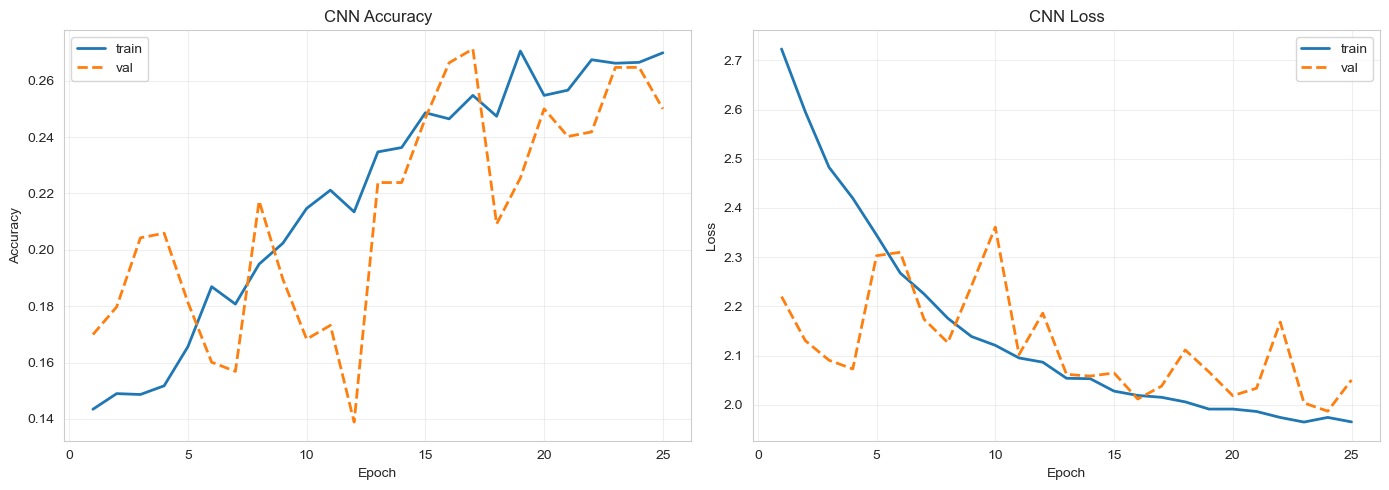

{'cnn_segment_macro_f1_test': 0.18112903160060076, 'cnn_track_macro_f1_test': 0.17494184820327197, 'track_rows': 326}
Worst classes by track-level F1 (CNN):


,genre,track_f1,track_recall
0,folk,0.000000,0.000000
1,indie,0.000000,0.000000
2,jazz,0.000000,0.000000
3,rock,0.000000,0.000000
4,pop,0.100000,0.058824
5,metal,0.325581,0.893617
6,electronic,0.330275,0.300000
7,classical,0.643678,0.700000


In [60]:
if RUN_SPECTROGRAM_CNN and RUN_CNN_EVAL:
    model_path = CNN_MAIN_DIR / 'final_model.keras'
    if not model_path.exists():
        raise FileNotFoundError(
            f'Missing CNN model: {model_path}. '            'Run Step 7b with RUN_CNN_FINETUNE_MAIN=True first.'
        )

    run_cmd([
        python_bin, '-m', 'src.models.evaluate_spectrogram_cnn',
        '--model_path', str(model_path),
        '--split_npz', str(MAIN_SPECTROGRAM_DIR / 'spectrogram_val.npz'),
        '--out_dir', str(CNN_MAIN_DIR / 'eval'),
        '--tag', 'val',
        '--batch_size', str(CNN_BATCH_SIZE),
    ])

    run_cmd([
        python_bin, '-m', 'src.models.evaluate_spectrogram_cnn',
        '--model_path', str(model_path),
        '--split_npz', str(MAIN_SPECTROGRAM_DIR / 'spectrogram_test.npz'),
        '--out_dir', str(CNN_MAIN_DIR / 'eval'),
        '--tag', 'test',
        '--batch_size', str(CNN_BATCH_SIZE),
    ])

    history_json = CNN_MAIN_DIR / 'history.json'
    if history_json.exists():
        hist = json.loads(history_json.read_text(encoding='utf-8'))
        epochs = list(range(1, len(hist.get('loss', [])) + 1))
        if epochs:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            axes[0].plot(epochs, hist.get('accuracy', []), label='train', linewidth=2)
            axes[0].plot(epochs, hist.get('val_accuracy', []), label='val', linewidth=2, linestyle='--')
            axes[0].set_title('CNN Accuracy')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Accuracy')
            axes[0].legend()
            axes[0].grid(alpha=0.3)

            axes[1].plot(epochs, hist.get('loss', []), label='train', linewidth=2)
            axes[1].plot(epochs, hist.get('val_loss', []), label='val', linewidth=2, linestyle='--')
            axes[1].set_title('CNN Loss')
            axes[1].set_xlabel('Epoch')
            axes[1].set_ylabel('Loss')
            axes[1].legend()
            axes[1].grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

    rep_test = CNN_MAIN_DIR / 'eval' / 'report_test.json'
    if rep_test.exists():
        report = json.loads(rep_test.read_text(encoding='utf-8'))
        print({
            'cnn_segment_macro_f1_test': report.get('segment_macro_f1'),
            'cnn_track_macro_f1_test': report.get('track_macro_f1'),
            'track_rows': report.get('rows_tracks'),
        })
        cls_rep = report.get('classification_report_track', {})
        ignore_keys = {'accuracy', 'macro avg', 'weighted avg'}
        class_order = [k for k in cls_rep.keys() if k not in ignore_keys]
        rows = []
        for g in class_order:
            rows.append({'genre': g, 'track_f1': cls_rep[g].get('f1-score', 0.0), 'track_recall': cls_rep[g].get('recall', 0.0)})
        if rows:
            worst = pd.DataFrame(rows).sort_values('track_f1').reset_index(drop=True)
            print('Worst classes by track-level F1 (CNN):')
            display(worst)
else:
    print('RUN_SPECTROGRAM_CNN=False or RUN_CNN_EVAL=False -> skipping CNN evaluation diagnostics.')


### Step 8c: 3-Way Late Fusion (Metadata + CLAP Audio + CNN) (Optional)

In [59]:
if RUN_SPECTROGRAM_CNN and RUN_CNN_FUSION:
    le = joblib.load(MODEL_DIR / 'label_encoder.joblib')
    known = set(le.classes_)

    scaler = joblib.load(MODEL_DIR / 'metadata_scaler.joblib')
    feature_cols = joblib.load(MODEL_DIR / 'metadata_feature_cols.joblib')
    train_medians = joblib.load(MODEL_DIR / 'metadata_train_medians.joblib')
    meta_model = joblib.load(MODEL_DIR / f'metadata_{FUSION_META_CLASSIFIER}.joblib')
    audio_model = joblib.load(MODEL_DIR / f'audio_{FUSION_AUDIO_CLASSIFIER}.joblib')
    audio_preproc = _load_audio_preprocessor(MODEL_DIR, FUSION_AUDIO_CLASSIFIER)

    id_to_indices, emb = load_embeddings(str(SELECTED_EMBEDDINGS_NPZ))

    def collect_split_probs(split_tag: str):
        split_csv = SPLITS_DIR / f'{split_tag}.csv'
        split_df = pd.read_csv(split_csv)
        base_df = build_track_level_audio_eval_df(split_df, known, set(id_to_indices))
        if len(base_df) == 0:
            raise RuntimeError(f'No aligned metadata+audio rows for split={split_tag}')

        X_meta_raw = get_metadata_X(base_df, feature_cols)
        X_meta = scaler.transform(X_meta_raw.fillna(train_medians).fillna(0.0))
        prob_meta = meta_model.predict_proba(X_meta)
        prob_audio = audio_probs_for_track_ids(
            base_df['track_id'], id_to_indices, emb, audio_model, audio_preprocessor=audio_preproc
        )

        cnn_probs_csv = CNN_MAIN_DIR / 'eval' / f'track_probs_{split_tag}.csv'
        if not cnn_probs_csv.exists():
            raise FileNotFoundError(f'Missing CNN track probs: {cnn_probs_csv}')
        cnn_df = pd.read_csv(cnn_probs_csv)

        cnn_prob_cols = [f'prob_{g}' for g in le.classes_]
        missing_cols = [c for c in cnn_prob_cols if c not in cnn_df.columns]
        if missing_cols:
            raise RuntimeError(
                f'CNN probability file for split={split_tag} is missing classes: {missing_cols}. '                'Fine-tuned CNN label space must match main label encoder.'
            )

        meta_audio_df = base_df[['track_id', 'genre']].copy().reset_index(drop=True)
        merged = meta_audio_df.merge(cnn_df[['track_id'] + cnn_prob_cols], on='track_id', how='inner')
        if len(merged) == 0:
            raise RuntimeError(f'No overlap between base modalities and CNN probs for split={split_tag}')

        idx_map = {tid: i for i, tid in enumerate(meta_audio_df['track_id'].astype(str).tolist())}
        idx = [idx_map[str(tid)] for tid in merged['track_id'].astype(str).tolist()]

        y_true = le.transform(merged['genre'])
        p_meta = prob_meta[idx]
        p_audio = prob_audio[idx]
        p_cnn = merged[cnn_prob_cols].to_numpy(dtype=np.float32)

        return y_true, p_meta, p_audio, p_cnn

    y_val, p_meta_val, p_audio_val, p_cnn_val = collect_split_probs('val')
    y_test, p_meta_test, p_audio_test, p_cnn_test = collect_split_probs('test')

    steps = max(2, int(CNN_FUSION_GRID_STEPS))
    best = {'f1': -1.0, 'wm': 0.34, 'wa': 0.33, 'wc': 0.33}
    for im in range(steps):
        wm = im / (steps - 1)
        for ia in range(steps - im):
            wa = ia / (steps - 1)
            wc = 1.0 - wm - wa
            if wc < -1e-9:
                continue
            wc = max(0.0, wc)
            p = wm * p_meta_val + wa * p_audio_val + wc * p_cnn_val
            f1 = f1_score(y_val, p.argmax(axis=1), average='macro')
            if f1 > best['f1']:
                best = {'f1': float(f1), 'wm': float(wm), 'wa': float(wa), 'wc': float(wc)}

    wm, wa, wc = best['wm'], best['wa'], best['wc']

    f1_meta_test = float(f1_score(y_test, p_meta_test.argmax(axis=1), average='macro'))
    f1_audio_test = float(f1_score(y_test, p_audio_test.argmax(axis=1), average='macro'))
    f1_cnn_test = float(f1_score(y_test, p_cnn_test.argmax(axis=1), average='macro'))
    p_fused_test = wm * p_meta_test + wa * p_audio_test + wc * p_cnn_test
    f1_fused_test = float(f1_score(y_test, p_fused_test.argmax(axis=1), average='macro'))

    payload = {
        'meta_classifier': FUSION_META_CLASSIFIER,
        'audio_classifier': FUSION_AUDIO_CLASSIFIER,
        'cnn_model_dir': str(CNN_MAIN_DIR),
        'weight_meta': wm,
        'weight_audio': wa,
        'weight_cnn': wc,
        'val_macro_f1': best['f1'],
        'test_macro_f1': f1_fused_test,
        'test_macro_f1_meta_only': f1_meta_test,
        'test_macro_f1_audio_only': f1_audio_test,
        'test_macro_f1_cnn_only': f1_cnn_test,
    }
    out_w = MODEL_DIR / f'fusion3_weights_meta-{FUSION_META_CLASSIFIER}_audio-{FUSION_AUDIO_CLASSIFIER}_cnn.joblib'
    joblib.dump(payload, out_w)

    out_json = MODEL_DIR / f'fusion3_report_meta-{FUSION_META_CLASSIFIER}_audio-{FUSION_AUDIO_CLASSIFIER}_cnn.json'
    out_json.write_text(json.dumps(payload, indent=2), encoding='utf-8')

    print('3-way fusion weights tuned on val:')
    print({'meta': wm, 'audio': wa, 'cnn': wc})
    print('Test macro F1 comparison:')
    print({'meta': f1_meta_test, 'audio': f1_audio_test, 'cnn': f1_cnn_test, 'fused3': f1_fused_test})
    print('Saved ->', out_w)
else:
    print('RUN_SPECTROGRAM_CNN=False or RUN_CNN_FUSION=False -> skipping 3-way fusion.')


3-way fusion weights tuned on val:
{'meta': 0.6, 'audio': 0.4, 'cnn': 0.0}
Test macro F1 comparison:
{'meta': 0.6431772424293176, 'audio': 0.5840284990208926, 'cnn': 0.17494184820327197, 'fused3': 0.6599624218968472}
Saved -> /Volumes/MZ Music/genre-classifier/models/full_run/fusion3_weights_meta-lightgbm_audio-mlp_cnn.joblib


## Step 9: Probability-Based Genre Analysis

Treat genre predictions as distributions (not only hard labels).

Outputs include:
- macro F1 + probabilistic metrics (negative log loss, ECE)
- reliability curve
- soft confusion matrix (mean predicted probabilities per true genre)
- confidence/uncertainty distributions
- most ambiguous tracks (small top-1 vs top-2 margin)


In [65]:
# Local imports so this cell can run independently after kernel restarts
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, log_loss

from src.models.evaluate import (
    load_embeddings,
    build_track_level_audio_eval_df,
    audio_probs_for_track_ids,
    _load_audio_preprocessor,
)
from src.models.train import get_metadata_X

required_vars = [
    'MODEL_DIR', 'SPLITS_DIR', 'SELECTED_EMBEDDINGS_NPZ',
    'METADATA_CLASSIFIER', 'AUDIO_CLASSIFIER',
    'FUSION_META_CLASSIFIER', 'FUSION_AUDIO_CLASSIFIER',
    'RUN_AUDIO_FUSION', 'AUDIO_FUSION_CLASSIFIER_A', 'AUDIO_FUSION_CLASSIFIER_B',
    'PROB_ANALYSIS_SPLIT', 'PROB_ANALYSIS_MODE', 'PROB_N_BINS', 'PROB_N_EXAMPLES',
    'PROB_FUSION_WEIGHT_META_OVERRIDE', 'PROB_AUDIO_FUSION_WEIGHT_A_OVERRIDE',
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing configuration variables for probability analysis: ' + ', '.join(missing)
        + '\nRun the Configuration and training/eval cells first.'
    )

if PROB_ANALYSIS_SPLIT == 'test':
    prob_test_csv = SPLITS_DIR / 'test.csv'
elif PROB_ANALYSIS_SPLIT == 'val':
    prob_test_csv = SPLITS_DIR / 'val.csv'
else:
    raise ValueError("PROB_ANALYSIS_SPLIT must be 'test' or 'val'")

if not prob_test_csv.exists():
    raise FileNotFoundError(f'Missing analysis split: {prob_test_csv}')
if not Path(SELECTED_EMBEDDINGS_NPZ).exists():
    raise FileNotFoundError(f'Missing analysis embeddings file: {SELECTED_EMBEDDINGS_NPZ}')

le = joblib.load(MODEL_DIR / 'label_encoder.joblib')
test_df = pd.read_csv(prob_test_csv)
id_to_indices, embeddings = load_embeddings(str(SELECTED_EMBEDDINGS_NPZ))
eval_df = build_track_level_audio_eval_df(test_df, set(le.classes_), set(id_to_indices))
if len(eval_df) == 0:
    raise RuntimeError('No rows left for analysis after filtering to known genres + embeddings.')

y_true = le.transform(eval_df['genre'])

if PROB_ANALYSIS_MODE == 'audio':
    model = joblib.load(MODEL_DIR / f'audio_{AUDIO_CLASSIFIER}.joblib')
    preproc = _load_audio_preprocessor(MODEL_DIR, AUDIO_CLASSIFIER)
    prob = audio_probs_for_track_ids(
        eval_df['track_id'], id_to_indices, embeddings, model, audio_preprocessor=preproc
    )
    prob_mode_tag = f'audio_{AUDIO_CLASSIFIER}'
    prob_weight_info = {'mode': 'single_model'}

elif PROB_ANALYSIS_MODE == 'fusion':
    meta_clf = FUSION_META_CLASSIFIER
    audio_clf = FUSION_AUDIO_CLASSIFIER
    scaler = joblib.load(MODEL_DIR / 'metadata_scaler.joblib')
    feature_cols = joblib.load(MODEL_DIR / 'metadata_feature_cols.joblib')
    train_medians = joblib.load(MODEL_DIR / 'metadata_train_medians.joblib')
    meta_model = joblib.load(MODEL_DIR / f'metadata_{meta_clf}.joblib')
    audio_model = joblib.load(MODEL_DIR / f'audio_{audio_clf}.joblib')
    audio_preprocessor = _load_audio_preprocessor(MODEL_DIR, audio_clf)

    X_meta_raw = get_metadata_X(eval_df, feature_cols)
    X_meta = scaler.transform(X_meta_raw.fillna(train_medians).fillna(0.0))
    prob_meta = meta_model.predict_proba(X_meta)
    prob_audio = audio_probs_for_track_ids(
        eval_df['track_id'], id_to_indices, embeddings, audio_model, audio_preprocessor=audio_preprocessor
    )

    weights_path = MODEL_DIR / f'fusion_weights_meta-{meta_clf}_audio-{audio_clf}.joblib'
    if PROB_FUSION_WEIGHT_META_OVERRIDE is not None:
        weight_meta = float(PROB_FUSION_WEIGHT_META_OVERRIDE)
        weight_source = 'override'
    elif weights_path.exists():
        payload = joblib.load(weights_path)
        weight_meta = float(payload.get('weight_meta', 0.5))
        weight_source = f'saved:{weights_path.name}'
    else:
        weight_meta = 0.5
        weight_source = 'default_equal'

    prob = weight_meta * prob_meta + (1.0 - weight_meta) * prob_audio
    prob_mode_tag = f'fusion_meta-{meta_clf}_audio-{audio_clf}'
    prob_weight_info = {'weight_meta': weight_meta, 'weight_audio': 1.0 - weight_meta, 'source': weight_source}

elif PROB_ANALYSIS_MODE == 'audio_fusion':
    clf_a = AUDIO_FUSION_CLASSIFIER_A
    clf_b = AUDIO_FUSION_CLASSIFIER_B
    model_a = joblib.load(MODEL_DIR / f'audio_{clf_a}.joblib')
    model_b = joblib.load(MODEL_DIR / f'audio_{clf_b}.joblib')
    preproc_a = _load_audio_preprocessor(MODEL_DIR, clf_a)
    preproc_b = _load_audio_preprocessor(MODEL_DIR, clf_b)

    prob_a = audio_probs_for_track_ids(
        eval_df['track_id'], id_to_indices, embeddings, model_a, audio_preprocessor=preproc_a
    )
    prob_b = audio_probs_for_track_ids(
        eval_df['track_id'], id_to_indices, embeddings, model_b, audio_preprocessor=preproc_b
    )

    weights_path = MODEL_DIR / f'audio_fusion_weights_audioA-{clf_a}_audioB-{clf_b}.joblib'
    if PROB_AUDIO_FUSION_WEIGHT_A_OVERRIDE is not None:
        weight_a = float(PROB_AUDIO_FUSION_WEIGHT_A_OVERRIDE)
        weight_source = 'override'
    elif weights_path.exists():
        payload = joblib.load(weights_path)
        weight_a = float(payload.get('weight_a', 0.5))
        weight_source = f'saved:{weights_path.name}'
    else:
        weight_a = 0.5
        weight_source = 'default_equal'

    prob = weight_a * prob_a + (1.0 - weight_a) * prob_b
    prob_mode_tag = f'audio_fusion_{clf_a}_{clf_b}'
    prob_weight_info = {'weight_a': weight_a, 'weight_b': 1.0 - weight_a, 'source': weight_source}

else:
    raise ValueError("PROB_ANALYSIS_MODE must be one of: audio, fusion, audio_fusion")

sorted_idx = np.argsort(prob, axis=1)
top1_idx = sorted_idx[:, -1]
top2_idx = sorted_idx[:, -2]
top3_idx = sorted_idx[:, -3:][:, ::-1]
confidence = prob[np.arange(len(prob)), top1_idx]
second_prob = prob[np.arange(len(prob)), top2_idx]
top2_margin = confidence - second_prob
entropy_norm = -np.sum(prob * np.log(np.clip(prob, 1e-12, 1.0)), axis=1) / np.log(prob.shape[1])

analysis_df = eval_df.copy()
analysis_df['pred_genre'] = le.inverse_transform(top1_idx)
analysis_df['confidence'] = confidence
analysis_df['top2_genre'] = le.inverse_transform(top2_idx)
analysis_df['top2_prob'] = second_prob
analysis_df['top2_margin'] = top2_margin
analysis_df['entropy_norm'] = entropy_norm
analysis_df['correct'] = (top1_idx == y_true)
for r in range(min(3, prob.shape[1])):
    idx_r = top3_idx[:, r]
    analysis_df[f'top{r+1}_genre'] = le.inverse_transform(idx_r)
    analysis_df[f'top{r+1}_prob'] = prob[np.arange(len(prob)), idx_r]

def compute_ece(y_true_idx: np.ndarray, prob_mat: np.ndarray, n_bins: int = 10):
    conf = prob_mat.max(axis=1)
    pred = prob_mat.argmax(axis=1)
    acc = (pred == y_true_idx).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == 0:
            mask = (conf >= lo) & (conf <= hi)
        else:
            mask = (conf > lo) & (conf <= hi)
        n = int(mask.sum())
        if n == 0:
            continue
        avg_conf = float(conf[mask].mean())
        avg_acc = float(acc[mask].mean())
        frac = n / len(conf)
        ece += frac * abs(avg_acc - avg_conf)
        rows.append({'bin': i, 'count': n, 'avg_conf': avg_conf, 'accuracy': avg_acc, 'bin_left': lo, 'bin_right': hi})
    return float(ece), pd.DataFrame(rows)

ece, cal_df = compute_ece(y_true, prob, n_bins=PROB_N_BINS)
macro_f1 = float(f1_score(y_true, top1_idx, average='macro'))
nll = float(log_loss(y_true, prob, labels=np.arange(len(le.classes_))))

{
    'split': PROB_ANALYSIS_SPLIT,
    'mode': prob_mode_tag,
    'rows_evaluated': int(len(analysis_df)),
    'macro_f1': round(macro_f1, 4),
    'negative_log_loss': round(nll, 4),
    'ece': round(float(ece), 4),
    'mean_confidence': round(float(analysis_df['confidence'].mean()), 4),
    'mean_entropy_norm': round(float(analysis_df['entropy_norm'].mean()), 4),
    'weight_info': prob_weight_info,
}


{'split': 'test',
 'mode': 'audio_fusion_logreg_mlp',
 'rows_evaluated': 326,
 'macro_f1': 0.6023,
 'negative_log_loss': 1.0729,
 'ece': 0.0514,
 'mean_confidence': 0.5732,
 'mean_entropy_norm': 0.5591,
 'weight_info': {'weight_a': 0.9500000000000001,
  'weight_b': 0.04999999999999993,
  'source': 'saved:audio_fusion_weights_audioA-logreg_audioB-mlp.joblib'}}

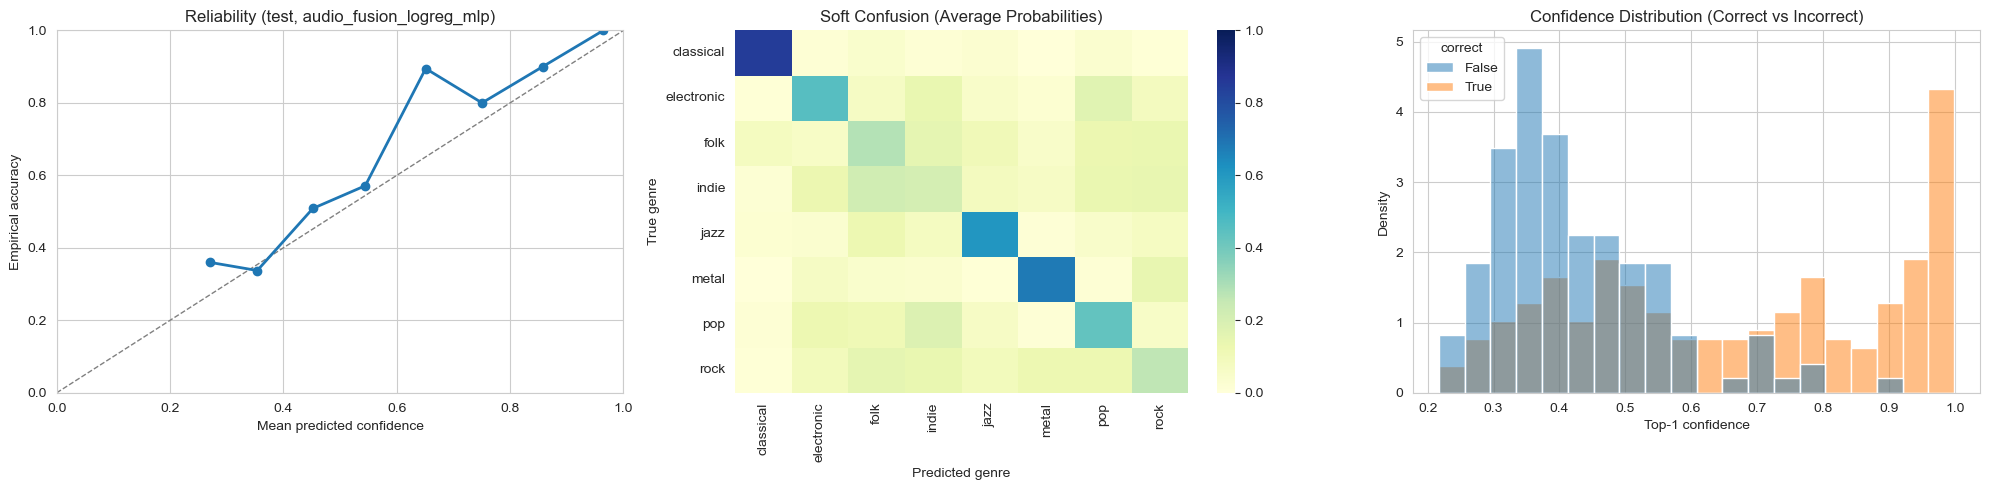

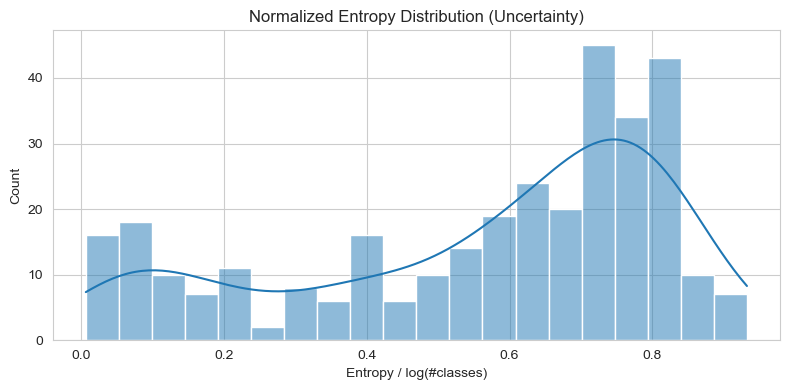

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
if len(cal_df) > 0:
    axes[0].plot(cal_df['avg_conf'], cal_df['accuracy'], marker='o', linewidth=2)
axes[0].set_title(f'Reliability ({PROB_ANALYSIS_SPLIT}, {prob_mode_tag})')
axes[0].set_xlabel('Mean predicted confidence')
axes[0].set_ylabel('Empirical accuracy')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

n_classes = len(le.classes_)
soft = np.zeros((n_classes, n_classes), dtype=float)
for i in range(n_classes):
    mask = y_true == i
    if mask.any():
        soft[i] = prob[mask].mean(axis=0)
soft_df = pd.DataFrame(soft, index=le.classes_, columns=le.classes_)
sns.heatmap(soft_df, cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1], cbar=True)
axes[1].set_title('Soft Confusion (Average Probabilities)')
axes[1].set_xlabel('Predicted genre')
axes[1].set_ylabel('True genre')

sns.histplot(data=analysis_df, x='confidence', hue='correct', bins=20, stat='density', common_norm=False, ax=axes[2])
axes[2].set_title('Confidence Distribution (Correct vs Incorrect)')
axes[2].set_xlabel('Top-1 confidence')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(analysis_df['entropy_norm'], bins=20, kde=True, ax=ax)
ax.set_title('Normalized Entropy Distribution (Uncertainty)')
ax.set_xlabel('Entropy / log(#classes)')
plt.tight_layout()
plt.show()


In [67]:
cols = [
    c for c in [
        'track_id', 'artist', 'title', 'genre', 'pred_genre',
        'confidence', 'top2_genre', 'top2_prob', 'top2_margin', 'entropy_norm',
        'top1_genre', 'top1_prob', 'top3_genre', 'top3_prob',
    ]
    if c in analysis_df.columns
]
ambiguous = analysis_df.sort_values(['top2_margin', 'confidence'], ascending=[True, True]).head(PROB_N_EXAMPLES)
print(f'Most ambiguous tracks (n={len(ambiguous)}):')
ambiguous[cols]


Most ambiguous tracks (n=15):


,track_id,artist,title,genre,pred_genre,confidence,top2_genre,top2_prob,top2_margin,entropy_norm,top1_genre,top1_prob,top3_genre,top3_prob
241,27k9Vb6ko9YYK6N8EJ8SA5,Bon Jovi,Always,metal,rock,0.291633,metal,0.288243,0.003389,0.823879,rock,0.291633,folk,0.155285
138,6dt2cKnkL79xajOcCutBUn,The Beach Boys,Little Saint Nick - 1991 Remix,rock,folk,0.354362,rock,0.350380,0.003983,0.726698,folk,0.354362,jazz,0.102137
115,5aQe0faFOjeskrHwpleXLJ,When Chai Met Toast,Yellow Paper Daisy,indie,indie,0.335897,folk,0.331041,0.004856,0.732863,indie,0.335897,rock,0.152051
169,0muK9BAzu2TJXQgWPsEj6e,Journey,Separate Ways (Worlds Apart) - Bryce Miller/Al...,rock,indie,0.285061,rock,0.280044,0.005017,0.798718,indie,0.285061,electronic,0.153250
19,1TVd8FHpeg1Afa92kaO0kR,Bibio,Petals,electronic,indie,0.238447,electronic,0.229412,0.009035,0.906115,indie,0.238447,pop,0.164469
92,3nqQXoyQOWXiESFLlDF1hG,Sam Smith,Unholy (feat. Kim Petras),pop,indie,0.304423,pop,0.290323,0.014099,0.775681,indie,0.304423,electronic,0.207997
116,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,I Wanna Be Yours,indie,folk,0.245485,indie,0.231284,0.014201,0.813693,folk,0.245485,rock,0.206677
175,27gHtbsHClwimHFtKgFop4,Brandi Carlile,You and Me on the Rock,folk,folk,0.246791,indie,0.232456,0.014335,0.821537,folk,0.246791,jazz,0.205382
200,7uUmZxPiY90voICTzpcN4y,Chico Teixeira,Último Adeus,folk,folk,0.323125,rock,0.307515,0.015610,0.761663,folk,0.323125,indie,0.180659
172,0mdDHZwtYpIZS7xD04LPxz,Mame Khan,Aave Re Hitchki,folk,folk,0.270129,indie,0.253983,0.016146,0.806580,folk,0.270129,pop,0.245513


## Step 10: Genre Cluster Map and Inter-Genre Distance

This projects per-track audio embeddings into 2D to visualize genre clusters.

It also annotates (with per-genre diversity):
- **genre-pure tracks** (high confidence, low entropy, correct)
- **ambiguous tracks** (small top-1 vs top-2 margin)

By default this uses per-genre top tracks, so labels are not dominated by a single genre.

Interpretation notes:
- **PCA-1** and **PCA-2** are the top two directions of variance in the standardized embedding space.
- They are **orthogonal latent axes** (linear combinations of all embedding dimensions), not single interpretable features like tempo.
- Nearby points indicate similar embeddings; centroid distances show how separated genres are in high-dimensional space.


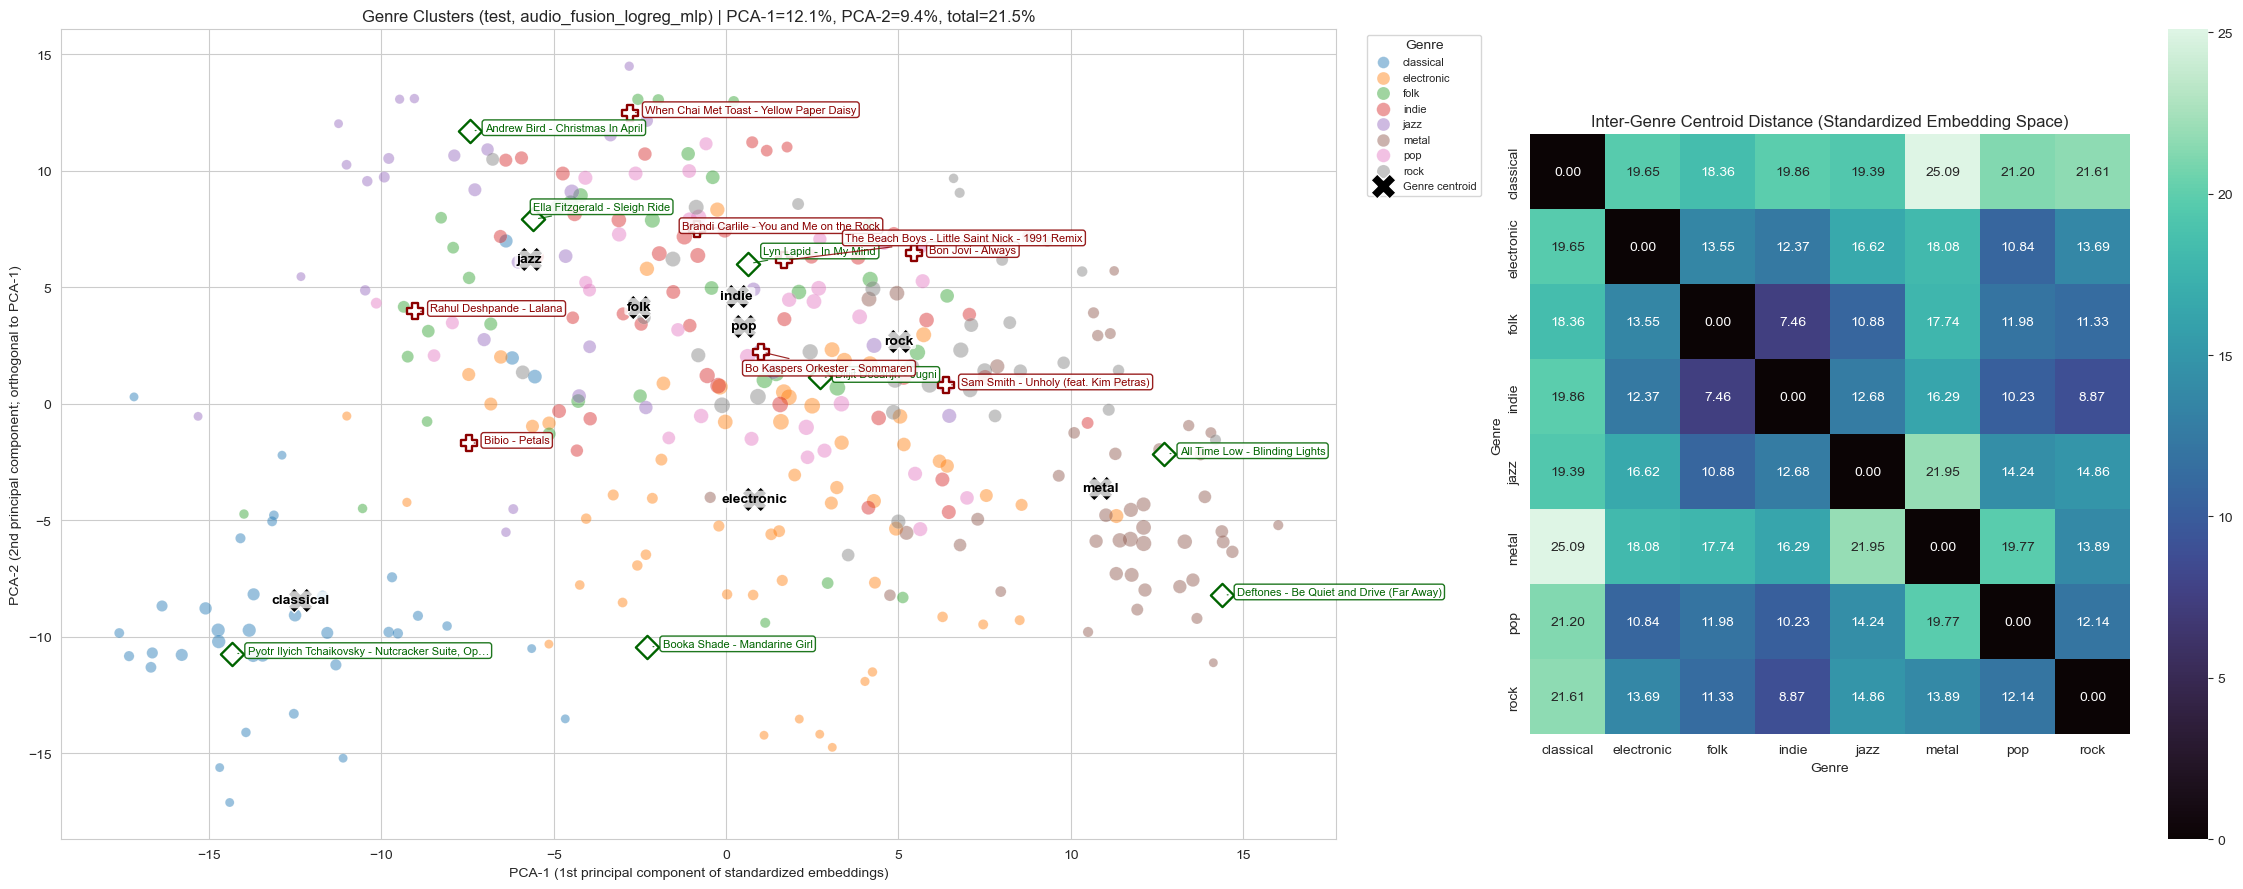

PCA interpretation: PCA-1 explains 12.1% and PCA-2 explains 9.4% of variance.
These axes are latent directions in embedding space (linear combinations of all embedding dimensions), not single hand-crafted features.
Label selection strategy: per_genre=True, pure_per_genre=1, ambiguous_per_genre=1
Point styling: palette=tab10, size_range=(42, 130), density_boost=True, k=20
Labeled pure tracks (green):


,track_id,artist,title,genre,pred_genre,confidence,top2_margin,entropy_norm
1,367ORcqkmIh0KCnb6KqREY,Pyotr Ilyich Tchaikovsky,"Nutcracker Suite, Op. 71a: Chinese Dance (Tea)",classical,classical,0.998324,0.996854,0.006325
3,5bDvBPW1eWPUbWYaqPjmXU,Booka Shade,Mandarine Girl,electronic,electronic,0.982665,0.976138,0.054658
5,0bb8X5e0tSxO8in2CSjJGl,Andrew Bird,Christmas In April,folk,folk,0.737558,0.569177,0.404814
7,2W779g2UrRZtVdf3FcEOO1,Lyn Lapid,In My Mind,indie,indie,0.409786,0.271361,0.793448
0,4tMBFkwGyBlZj2Rl1R7mwP,Ella Fitzgerald,Sleigh Ride,jazz,jazz,0.998498,0.997560,0.006271
2,4Uiw0Sl9yskBaC6P4DcdVD,Deftones,Be Quiet and Drive (Far Away),metal,metal,0.990348,0.982519,0.029107
4,0gHFDbhx2RFBrhJplPxlcT,Diljit Dosanjh,Jugni,pop,pop,0.782407,0.690305,0.377513
6,3bkgyThZ4ImhlQNgVRo850,All Time Low,Blinding Lights,rock,rock,0.572742,0.352748,0.600630


Labeled ambiguous tracks (red):


,track_id,artist,title,genre,pred_genre,confidence,top2_margin,entropy_norm
6,2P7MjfY0QD7jPeYfksJDdV,Rahul Deshpande,Lalana,classical,classical,0.313731,0.024671,0.705883
3,1TVd8FHpeg1Afa92kaO0kR,Bibio,Petals,electronic,indie,0.238447,0.009035,0.906115
5,27gHtbsHClwimHFtKgFop4,Brandi Carlile,You and Me on the Rock,folk,folk,0.246791,0.014335,0.821537
2,5aQe0faFOjeskrHwpleXLJ,When Chai Met Toast,Yellow Paper Daisy,indie,indie,0.335897,0.004856,0.732863
7,5BT0sejkliP4fAzR59DW1N,Bo Kaspers Orkester,Sommaren,jazz,folk,0.356757,0.069837,0.745625
0,27k9Vb6ko9YYK6N8EJ8SA5,Bon Jovi,Always,metal,rock,0.291633,0.003389,0.823879
4,3nqQXoyQOWXiESFLlDF1hG,Sam Smith,Unholy (feat. Kim Petras),pop,indie,0.304423,0.014099,0.775681
1,6dt2cKnkL79xajOcCutBUn,The Beach Boys,Little Saint Nick - 1991 Remix,rock,folk,0.354362,0.003983,0.726698


In [68]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

required_vars = [
    'analysis_df', 'eval_df', 'id_to_indices', 'embeddings', 'le',
    'CLUSTER_LABELS_PURE', 'CLUSTER_LABELS_AMBIG', 'CLUSTER_POINT_ALPHA', 'CLUSTER_RANDOM_STATE',
    'CLUSTER_LABEL_MIN_SEP', 'CLUSTER_LABEL_FONT_SIZE', 'CLUSTER_LABEL_MAX_LEN',
    'CLUSTER_DIVERSITY_BY_GENRE', 'CLUSTER_PURE_PER_GENRE', 'CLUSTER_AMBIG_PER_GENRE',
    'CLUSTER_PALETTE', 'CLUSTER_POINT_SIZE_MIN', 'CLUSTER_POINT_SIZE_MAX',
    'CLUSTER_DENSITY_SIZE_BOOST', 'CLUSTER_DENSITY_K', 'CLUSTER_CENTROID_SIZE', 'CLUSTER_POINT_EDGE_WIDTH',
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError('Run Step 9 + Configuration first. Missing: ' + ', '.join(missing))

track_ids = eval_df['track_id'].astype(str).tolist()
track_emb = np.vstack([embeddings[id_to_indices[tid]].mean(axis=0) for tid in track_ids]).astype(np.float32)
scaler = StandardScaler()
track_emb_z = scaler.fit_transform(track_emb)
pca2 = PCA(n_components=2, random_state=CLUSTER_RANDOM_STATE)
xy = pca2.fit_transform(track_emb_z)
var1, var2 = pca2.explained_variance_ratio_

plot_df = analysis_df.copy().reset_index(drop=True)
plot_df['x'] = xy[:, 0]
plot_df['y'] = xy[:, 1]

# Density-aware point sizing: denser neighborhoods get larger markers.
point_sizes = np.full(len(plot_df), float(CLUSTER_POINT_SIZE_MIN), dtype=np.float32)
k_used = None
if bool(CLUSTER_DENSITY_SIZE_BOOST) and len(plot_df) > 3:
    k_used = int(max(3, min(int(CLUSTER_DENSITY_K), len(plot_df) - 1)))
    nbrs = NearestNeighbors(n_neighbors=k_used + 1)
    xy_np = plot_df[['x', 'y']].to_numpy(dtype=np.float32)
    nbrs.fit(xy_np)
    dists, _ = nbrs.kneighbors(xy_np)
    mean_neighbor_dist = dists[:, 1:].mean(axis=1)
    density_raw = 1.0 / np.maximum(mean_neighbor_dist, 1e-9)

    lo = float(np.quantile(density_raw, 0.05))
    hi = float(np.quantile(density_raw, 0.95))
    density_clip = np.clip(density_raw, lo, hi)
    span = float(density_clip.max() - density_clip.min())
    if span > 1e-12:
        norm = (density_clip - density_clip.min()) / span
    else:
        norm = np.zeros_like(density_clip)

    point_sizes = float(CLUSTER_POINT_SIZE_MIN) + norm * float(CLUSTER_POINT_SIZE_MAX - CLUSTER_POINT_SIZE_MIN)

plot_df['point_size'] = point_sizes

cent2 = plot_df.groupby('genre')[['x', 'y']].mean().sort_index()
genres = cent2.index.tolist()
cent_high = np.vstack([track_emb_z[plot_df['genre'].values == g].mean(axis=0) for g in genres])
dist = pairwise_distances(cent_high, metric='euclidean')
dist_df = pd.DataFrame(dist, index=genres, columns=genres)

pure_candidates = plot_df[plot_df['correct']].copy().sort_values(
    ['confidence', 'top2_margin', 'entropy_norm'], ascending=[False, False, True]
)
ambig_candidates = plot_df.sort_values(
    ['top2_margin', 'entropy_norm', 'confidence'], ascending=[True, False, True]
)

use_diversity = bool(CLUSTER_DIVERSITY_BY_GENRE)
pure_per_genre = int(CLUSTER_PURE_PER_GENRE)
ambig_per_genre = int(CLUSTER_AMBIG_PER_GENRE)
if pure_per_genre < 1 or ambig_per_genre < 1:
    raise ValueError('CLUSTER_PURE_PER_GENRE and CLUSTER_AMBIG_PER_GENRE must be >= 1')

def _select_per_genre(df, sort_cols, ascending, k):
    ranked = df.sort_values(sort_cols, ascending=ascending)
    return ranked.groupby('genre', group_keys=False).head(k).reset_index(drop=True)

if use_diversity:
    pure_sel = _select_per_genre(
        pure_candidates,
        ['confidence', 'top2_margin', 'entropy_norm'],
        [False, False, True],
        pure_per_genre,
    )
    ambig_sel = _select_per_genre(
        ambig_candidates,
        ['top2_margin', 'entropy_norm', 'confidence'],
        [True, False, True],
        ambig_per_genre,
    )
else:
    pure_sel = pure_candidates.head(CLUSTER_LABELS_PURE).copy()
    ambig_sel = ambig_candidates.head(CLUSTER_LABELS_AMBIG).copy()

def _song_label(row):
    artist = str(row.get('artist', '')).strip()
    title = str(row.get('title', '')).strip()
    if artist and artist.lower() != 'nan':
        label = f"{artist} - {title}" if title and title.lower() != 'nan' else artist
    else:
        label = title if title and title.lower() != 'nan' else str(row.get('track_id', 'track'))
    max_len = int(CLUSTER_LABEL_MAX_LEN)
    return (label[: max_len - 1] + '…') if len(label) > max_len else label

def place_labels_with_repulsion(ax, rows_df, color, marker, placed_positions, priority_col=None):
    if len(rows_df) == 0:
        return
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xr = max(xlim[1] - xlim[0], 1e-9)
    yr = max(ylim[1] - ylim[0], 1e-9)
    dirs = [
        (1, 0), (-1, 0), (0, 1), (0, -1),
        (1, 1), (-1, 1), (1, -1), (-1, -1),
        (2, 1), (-2, 1), (2, -1), (-2, -1),
        (1, 2), (-1, 2), (1, -2), (-1, -2),
    ]
    if priority_col is not None and priority_col in rows_df.columns:
        rows_df = rows_df.sort_values(priority_col, ascending=False)

    ax.scatter(rows_df['x'], rows_df['y'], s=140, marker=marker, c='white', edgecolors=color, linewidths=1.7, zorder=5)
    min_sep = float(CLUSTER_LABEL_MIN_SEP)

    for _, r in rows_df.iterrows():
        x0, y0 = float(r['x']), float(r['y'])
        best = None
        best_score = -1e9
        for ring in range(1, 8):
            scale = 0.012 * ring
            for dxu, dyu in dirs:
                tx = x0 + dxu * scale * xr
                ty = y0 + dyu * scale * yr
                pad_x = 0.02 * xr
                pad_y = 0.02 * yr
                tx = min(max(tx, xlim[0] + pad_x), xlim[1] - pad_x)
                ty = min(max(ty, ylim[0] + pad_y), ylim[1] - pad_y)
                if placed_positions:
                    dmin = min(((((tx - px) / xr) ** 2 + ((ty - py) / yr) ** 2) ** 0.5) for px, py in placed_positions)
                else:
                    dmin = 1.0
                if dmin >= min_sep:
                    best = (tx, ty)
                    best_score = dmin
                    break
                if dmin > best_score:
                    best = (tx, ty)
                    best_score = dmin
            if best_score >= min_sep:
                break

        tx, ty = best
        ax.annotate(
            _song_label(r),
            xy=(x0, y0),
            xytext=(tx, ty),
            textcoords='data',
            fontsize=CLUSTER_LABEL_FONT_SIZE,
            color=color,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.88, edgecolor=color, linewidth=1.0),
            arrowprops=dict(arrowstyle='-', color=color, linewidth=0.85, alpha=0.85, shrinkA=4, shrinkB=4),
            zorder=6,
        )
        placed_positions.append((tx, ty))

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(23, 9), gridspec_kw={'width_ratios': [1.7, 1.0]})

genre_order = sorted(plot_df['genre'].dropna().unique().tolist())
palette = sns.color_palette(CLUSTER_PALETTE, n_colors=max(3, len(genre_order)))
genre_to_color = {g: palette[i] for i, g in enumerate(genre_order)}

for g in genre_order:
    gdf = plot_df[plot_df['genre'] == g]
    axes[0].scatter(
        gdf['x'],
        gdf['y'],
        s=gdf['point_size'],
        c=[genre_to_color[g]],
        alpha=CLUSTER_POINT_ALPHA,
        edgecolors='white',
        linewidths=float(CLUSTER_POINT_EDGE_WIDTH),
        label=g,
        zorder=2,
    )

axes[0].scatter(
    cent2['x'],
    cent2['y'],
    marker='X',
    s=float(CLUSTER_CENTROID_SIZE),
    c='black',
    edgecolors='white',
    linewidths=0.9,
    label='Genre centroid',
    zorder=4,
)

for g, row in cent2.iterrows():
    axes[0].text(
        row['x'],
        row['y'],
        g,
        fontsize=10,
        weight='bold',
        ha='center',
        va='center',
        color='black',
        bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.78, edgecolor='none'),
        zorder=5,
    )

x_margin = 0.05 * max(plot_df['x'].max() - plot_df['x'].min(), 1e-9)
y_margin = 0.05 * max(plot_df['y'].max() - plot_df['y'].min(), 1e-9)
axes[0].set_xlim(plot_df['x'].min() - x_margin, plot_df['x'].max() + x_margin)
axes[0].set_ylim(plot_df['y'].min() - y_margin, plot_df['y'].max() + y_margin)

placed = [(float(r['x']), float(r['y'])) for _, r in cent2.iterrows()]
place_labels_with_repulsion(axes[0], pure_sel, color='darkgreen', marker='D', placed_positions=placed, priority_col='confidence')
place_labels_with_repulsion(axes[0], ambig_sel, color='darkred', marker='P', placed_positions=placed, priority_col='entropy_norm')

axes[0].set_title(
    f"Genre Clusters ({PROB_ANALYSIS_SPLIT}, {prob_mode_tag}) | PCA-1={var1:.1%}, PCA-2={var2:.1%}, total={var1+var2:.1%}",
    fontsize=12,
)
axes[0].set_xlabel('PCA-1 (1st principal component of standardized embeddings)')
axes[0].set_ylabel('PCA-2 (2nd principal component; orthogonal to PCA-1)')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=True, title='Genre')

sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='mako', square=True, ax=axes[1])
axes[1].set_title('Inter-Genre Centroid Distance (Standardized Embedding Space)')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Genre')

plt.tight_layout()
plt.show()

print(f'PCA interpretation: PCA-1 explains {var1:.1%} and PCA-2 explains {var2:.1%} of variance.')
print('These axes are latent directions in embedding space (linear combinations of all embedding dimensions), not single hand-crafted features.')
print(f'Label selection strategy: per_genre={use_diversity}, pure_per_genre={pure_per_genre}, ambiguous_per_genre={ambig_per_genre}')
print(
    f"Point styling: palette={CLUSTER_PALETTE}, size_range=({CLUSTER_POINT_SIZE_MIN}, {CLUSTER_POINT_SIZE_MAX}), "
    f"density_boost={CLUSTER_DENSITY_SIZE_BOOST}, k={k_used if k_used is not None else 'n/a'}"
)

print('Labeled pure tracks (green):')
display(pure_sel[['track_id','artist','title','genre','pred_genre','confidence','top2_margin','entropy_norm']].sort_values(['genre','confidence'], ascending=[True, False]))
print('Labeled ambiguous tracks (red):')
display(ambig_sel[['track_id','artist','title','genre','pred_genre','confidence','top2_margin','entropy_norm']].sort_values(['genre','top2_margin'], ascending=[True, True]))


## Step 11: Executive Summary, Implications, and Error Analysis

This section consolidates model performance and dataset behavior in one place for final reporting.

- Model-level comparison on one split (`macro_f1`, `weighted_f1`, `accuracy`, `n_eval`).
- Per-genre comparison across available models.
- Confusion-matrix analysis of genre overlap (directed + mutual bleed pairs).
- In-line artefact checklist so outputs are documented where conclusions are made.

In [69]:
# Consolidate predictions across available models on the same split.
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from src.models.evaluate import (
    _load_audio_preprocessor,
    audio_probs_for_track_ids,
    build_track_level_audio_eval_df,
    load_embeddings,
)
from src.models.train import get_metadata_X

required_vars = ['MODEL_DIR', 'SPLITS_DIR', 'SELECTED_EMBEDDINGS_NPZ']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError('Run Configuration first. Missing: ' + ', '.join(missing))

SUMMARY_SPLIT = globals().get('PROB_ANALYSIS_SPLIT', 'test')
if SUMMARY_SPLIT not in {'test', 'val'}:
    SUMMARY_SPLIT = 'test'

split_csv = SPLITS_DIR / f'{SUMMARY_SPLIT}.csv'
if not split_csv.exists():
    raise FileNotFoundError(f'Missing split for summary analysis: {split_csv}')
if not Path(SELECTED_EMBEDDINGS_NPZ).exists():
    raise FileNotFoundError(f'Missing embeddings file: {SELECTED_EMBEDDINGS_NPZ}')

le = joblib.load(MODEL_DIR / 'label_encoder.joblib')
SUMMARY_LABELS = list(le.classes_)
n_classes = len(SUMMARY_LABELS)

split_df = pd.read_csv(split_csv)
id_to_indices, embeddings = load_embeddings(str(SELECTED_EMBEDDINGS_NPZ))
summary_eval_df = build_track_level_audio_eval_df(split_df, set(le.classes_), set(id_to_indices))
if len(summary_eval_df) == 0:
    raise RuntimeError('No aligned rows found for summary analysis.')

track_ids_full = summary_eval_df['track_id'].astype(str).to_numpy()
y_true_full = le.transform(summary_eval_df['genre'])


def _normalize_prob(prob_mat: np.ndarray) -> np.ndarray:
    p = np.asarray(prob_mat, dtype=np.float32)
    p = np.nan_to_num(p, nan=0.0, posinf=0.0, neginf=0.0)
    row_sum = np.clip(p.sum(axis=1, keepdims=True), 1e-12, None)
    return p / row_sum


def _align_prob_to_encoder(model, prob_mat: np.ndarray, n_labels: int) -> np.ndarray:
    p = np.asarray(prob_mat, dtype=np.float32)
    classes = getattr(model, 'classes_', None)
    if classes is None:
        return p
    classes = np.asarray(classes)
    if classes.shape[0] == n_labels and np.array_equal(classes, np.arange(n_labels)):
        return p

    aligned = np.zeros((p.shape[0], n_labels), dtype=np.float32)
    for src_col, cls_id in enumerate(classes.tolist()):
        cls_int = int(cls_id)
        if 0 <= cls_int < n_labels:
            aligned[:, cls_int] = p[:, src_col]
    return aligned


def _add_output(storage: dict, name: str, y_true_idx: np.ndarray, tids: np.ndarray, prob_mat: np.ndarray):
    p = _normalize_prob(prob_mat)
    if p.ndim != 2 or p.shape[1] != n_classes:
        raise RuntimeError(f'Unexpected probability shape for {name}: {p.shape}')
    storage[name] = {
        'y_true': np.asarray(y_true_idx, dtype=np.int32),
        'track_ids': np.asarray(tids, dtype=str),
        'prob': p,
    }


metadata_clfs = sorted({
    m.group(1)
    for path in MODEL_DIR.glob('metadata_*.joblib')
    for m in [re.fullmatch(r'metadata_(lightgbm|logreg|mlp)\.joblib', path.name)]
    if m
})
audio_clfs = sorted({
    m.group(1)
    for path in MODEL_DIR.glob('audio_*.joblib')
    for m in [re.fullmatch(r'audio_(lightgbm|logreg|mlp)\.joblib', path.name)]
    if m
})

model_outputs = {}
weight_notes = {}
metadata_probs = {}
audio_probs = {}

# Metadata model probabilities (if metadata artefacts exist).
if metadata_clfs:
    scaler_path = MODEL_DIR / 'metadata_scaler.joblib'
    feature_cols_path = MODEL_DIR / 'metadata_feature_cols.joblib'
    train_medians_path = MODEL_DIR / 'metadata_train_medians.joblib'
    if scaler_path.exists() and feature_cols_path.exists() and train_medians_path.exists():
        scaler = joblib.load(scaler_path)
        feature_cols = joblib.load(feature_cols_path)
        train_medians = joblib.load(train_medians_path)
        X_meta_raw = get_metadata_X(summary_eval_df, feature_cols)
        X_meta = scaler.transform(X_meta_raw.fillna(train_medians).fillna(0.0))

        for clf in metadata_clfs:
            model_path = MODEL_DIR / f'metadata_{clf}.joblib'
            try:
                model = joblib.load(model_path)
                p = model.predict_proba(X_meta)
                p = _align_prob_to_encoder(model, p, n_classes)
                metadata_probs[clf] = _normalize_prob(p)
                _add_output(model_outputs, f'metadata_{clf}', y_true_full, track_ids_full, metadata_probs[clf])
            except Exception as exc:
                print(f'Skipping metadata_{clf}: {exc}')
    else:
        print('Metadata preprocessing artefacts not found; skipping metadata models.')

# Audio model probabilities (window-level to track-level mean pooling).
for clf in audio_clfs:
    model_path = MODEL_DIR / f'audio_{clf}.joblib'
    try:
        model = joblib.load(model_path)
        preproc = _load_audio_preprocessor(MODEL_DIR, clf)
        p = audio_probs_for_track_ids(
            summary_eval_df['track_id'],
            id_to_indices,
            embeddings,
            model,
            audio_preprocessor=preproc,
        )
        p = _align_prob_to_encoder(model, p, n_classes)
        audio_probs[clf] = _normalize_prob(p)
        _add_output(model_outputs, f'audio_{clf}', y_true_full, track_ids_full, audio_probs[clf])
    except Exception as exc:
        print(f'Skipping audio_{clf}: {exc}')

# Metadata+audio late fusion.
fusion_pairs = set()
if 'FUSION_META_CLASSIFIER' in globals() and 'FUSION_AUDIO_CLASSIFIER' in globals():
    fusion_pairs.add((str(FUSION_META_CLASSIFIER), str(FUSION_AUDIO_CLASSIFIER)))
for path in MODEL_DIR.glob('fusion_weights_meta-*_audio-*.joblib'):
    m = re.fullmatch(r'fusion_weights_meta-(lightgbm|logreg|mlp)_audio-(lightgbm|logreg|mlp)\.joblib', path.name)
    if m:
        fusion_pairs.add((m.group(1), m.group(2)))

for meta_clf, audio_clf in sorted(fusion_pairs):
    if meta_clf not in metadata_probs or audio_clf not in audio_probs:
        continue
    weights_path = MODEL_DIR / f'fusion_weights_meta-{meta_clf}_audio-{audio_clf}.joblib'
    wm = 0.5
    source = 'default_equal'
    if weights_path.exists():
        payload = joblib.load(weights_path)
        wm = float(payload.get('weight_meta', 0.5))
        source = f'saved:{weights_path.name}'
    wm = float(np.clip(wm, 0.0, 1.0))
    wa = 1.0 - wm
    fused = wm * metadata_probs[meta_clf] + wa * audio_probs[audio_clf]
    tag = f'fusion_meta-{meta_clf}_audio-{audio_clf}'
    _add_output(model_outputs, tag, y_true_full, track_ids_full, fused)
    weight_notes[tag] = f'meta={wm:.3f}, audio={wa:.3f} ({source})'

# Audio+audio late fusion.
audio_fusion_pairs = set()
if 'AUDIO_FUSION_CLASSIFIER_A' in globals() and 'AUDIO_FUSION_CLASSIFIER_B' in globals():
    audio_fusion_pairs.add((str(AUDIO_FUSION_CLASSIFIER_A), str(AUDIO_FUSION_CLASSIFIER_B)))
for path in MODEL_DIR.glob('audio_fusion_weights_audioA-*_audioB-*.joblib'):
    m = re.fullmatch(r'audio_fusion_weights_audioA-(lightgbm|logreg|mlp)_audioB-(lightgbm|logreg|mlp)\.joblib', path.name)
    if m:
        audio_fusion_pairs.add((m.group(1), m.group(2)))

for clf_a, clf_b in sorted(audio_fusion_pairs):
    if clf_a not in audio_probs or clf_b not in audio_probs:
        continue
    weights_path = MODEL_DIR / f'audio_fusion_weights_audioA-{clf_a}_audioB-{clf_b}.joblib'
    wa = 0.5
    source = 'default_equal'
    if weights_path.exists():
        payload = joblib.load(weights_path)
        wa = float(payload.get('weight_a', 0.5))
        source = f'saved:{weights_path.name}'
    wa = float(np.clip(wa, 0.0, 1.0))
    wb = 1.0 - wa
    fused = wa * audio_probs[clf_a] + wb * audio_probs[clf_b]
    tag = f'audio_fusion_audioA-{clf_a}_audioB-{clf_b}'
    _add_output(model_outputs, tag, y_true_full, track_ids_full, fused)
    weight_notes[tag] = f'{clf_a}={wa:.3f}, {clf_b}={wb:.3f} ({source})'

# CNN probabilities (if cached eval CSV exists for this split).
cnn_prob = None
cnn_mask = None
cnn_root = Path(globals().get('CNN_MAIN_DIR', MODEL_DIR / 'cnn_main'))
cnn_probs_csv = cnn_root / 'eval' / f'track_probs_{SUMMARY_SPLIT}.csv'
if cnn_probs_csv.exists():
    cnn_df = pd.read_csv(cnn_probs_csv)
    cnn_df['track_id'] = cnn_df['track_id'].astype(str)
    prob_cols = [f'prob_{g}' for g in SUMMARY_LABELS]
    missing_prob_cols = [c for c in prob_cols if c not in cnn_df.columns]
    if not missing_prob_cols:
        ordered = pd.DataFrame({'track_id': track_ids_full}).merge(
            cnn_df[['track_id'] + prob_cols],
            on='track_id',
            how='left',
        )
        valid = ordered[prob_cols].notna().all(axis=1).to_numpy()
        if valid.any():
            cnn_prob = ordered.loc[valid, prob_cols].to_numpy(dtype=np.float32)
            cnn_mask = valid
            _add_output(model_outputs, 'cnn_main', y_true_full[valid], track_ids_full[valid], cnn_prob)
        else:
            print(f'CNN probs found at {cnn_probs_csv} but no aligned track_ids for this split.')
    else:
        print(f'CNN probs file missing columns: {missing_prob_cols}')
else:
    print(f'No CNN probability CSV found at: {cnn_probs_csv}')

# Optional 3-way fusion (metadata + audio + cnn).
if cnn_prob is not None and cnn_mask is not None:
    candidates = {}
    for path in MODEL_DIR.glob('fusion3_weights_meta-*_audio-*_cnn.joblib'):
        m = re.fullmatch(r'fusion3_weights_meta-(lightgbm|logreg|mlp)_audio-(lightgbm|logreg|mlp)_cnn\.joblib', path.name)
        if m:
            candidates[(m.group(1), m.group(2))] = path
    if 'FUSION_META_CLASSIFIER' in globals() and 'FUSION_AUDIO_CLASSIFIER' in globals():
        cfg_path = MODEL_DIR / f'fusion3_weights_meta-{FUSION_META_CLASSIFIER}_audio-{FUSION_AUDIO_CLASSIFIER}_cnn.joblib'
        candidates[(str(FUSION_META_CLASSIFIER), str(FUSION_AUDIO_CLASSIFIER))] = cfg_path

    for (meta_clf, audio_clf), path in sorted(candidates.items()):
        if meta_clf not in metadata_probs or audio_clf not in audio_probs:
            continue
        wm, wa, wc = 1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0
        source = 'default_equal'
        if path.exists():
            payload = joblib.load(path)
            wm = float(payload.get('weight_meta', wm))
            wa = float(payload.get('weight_audio', wa))
            wc = float(payload.get('weight_cnn', wc))
            source = f'saved:{path.name}'
        total = wm + wa + wc
        if total <= 1e-12:
            wm, wa, wc = 1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0
        else:
            wm, wa, wc = wm / total, wa / total, wc / total

        fused = wm * metadata_probs[meta_clf][cnn_mask] + wa * audio_probs[audio_clf][cnn_mask] + wc * cnn_prob
        tag = f'fusion3_meta-{meta_clf}_audio-{audio_clf}_cnn'
        _add_output(model_outputs, tag, y_true_full[cnn_mask], track_ids_full[cnn_mask], fused)
        weight_notes[tag] = f'meta={wm:.3f}, audio={wa:.3f}, cnn={wc:.3f} ({source})'

summary_rows = []
per_genre_rows = []
cm_by_model = {}

for model_name, payload in model_outputs.items():
    y_t = payload['y_true']
    p = payload['prob']
    y_hat = p.argmax(axis=1)

    summary_rows.append({
        'model': model_name,
        'macro_f1': float(f1_score(y_t, y_hat, average='macro')),
        'weighted_f1': float(f1_score(y_t, y_hat, average='weighted')),
        'accuracy': float(accuracy_score(y_t, y_hat)),
        'n_eval': int(len(y_t)),
        'weights': weight_notes.get(model_name, ''),
    })

    rep = classification_report(
        y_t,
        y_hat,
        labels=np.arange(n_classes),
        target_names=SUMMARY_LABELS,
        output_dict=True,
        zero_division=0,
    )

    for g in SUMMARY_LABELS:
        stats = rep.get(g, {})
        per_genre_rows.append({
            'model': model_name,
            'genre': g,
            'precision': float(stats.get('precision', 0.0)),
            'recall': float(stats.get('recall', 0.0)),
            'f1': float(stats.get('f1-score', 0.0)),
            'support': int(stats.get('support', 0)),
        })

    cm_by_model[model_name] = confusion_matrix(
        y_t,
        y_hat,
        labels=np.arange(n_classes),
        normalize='true',
    )

if not summary_rows:
    raise RuntimeError('No model outputs available for summary section.')

SUMMARY_MODEL_TABLE = pd.DataFrame(summary_rows).sort_values(
    ['macro_f1', 'accuracy'], ascending=[False, False]
).reset_index(drop=True)
SUMMARY_PER_GENRE_TABLE = pd.DataFrame(per_genre_rows)
SUMMARY_GENRE_F1_TABLE = (
    SUMMARY_PER_GENRE_TABLE
    .pivot(index='genre', columns='model', values='f1')
    .reindex(SUMMARY_LABELS)
)

SUMMARY_BEST_MODEL = str(SUMMARY_MODEL_TABLE.iloc[0]['model'])
SUMMARY_BEST_CM = cm_by_model[SUMMARY_BEST_MODEL]


def _directed_bleed(cm: np.ndarray, labels: list[str]) -> pd.DataFrame:
    rows = []
    n = len(labels)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            rows.append({'from_genre': labels[i], 'to_genre': labels[j], 'confusion_rate': float(cm[i, j])})
    return pd.DataFrame(rows).sort_values('confusion_rate', ascending=False).reset_index(drop=True)


def _mutual_bleed(cm: np.ndarray, labels: list[str]) -> pd.DataFrame:
    rows = []
    n = len(labels)
    for i in range(n):
        for j in range(i + 1, n):
            a_to_b = float(cm[i, j])
            b_to_a = float(cm[j, i])
            rows.append({
                'genre_a': labels[i],
                'genre_b': labels[j],
                'a_to_b': a_to_b,
                'b_to_a': b_to_a,
                'mutual_bleed': 0.5 * (a_to_b + b_to_a),
            })
    return pd.DataFrame(rows).sort_values('mutual_bleed', ascending=False).reset_index(drop=True)


SUMMARY_BLEED_DIRECT = _directed_bleed(SUMMARY_BEST_CM, SUMMARY_LABELS)
SUMMARY_BLEED_MUTUAL = _mutual_bleed(SUMMARY_BEST_CM, SUMMARY_LABELS)

best_payload = model_outputs[SUMMARY_BEST_MODEL]
best_prob = best_payload['prob']
best_y = best_payload['y_true']
best_pred = best_prob.argmax(axis=1)
best_conf = best_prob.max(axis=1)
best_sorted = np.sort(best_prob, axis=1)
best_margin = best_sorted[:, -1] - best_sorted[:, -2]
best_entropy = -np.sum(best_prob * np.log(np.clip(best_prob, 1e-12, 1.0)), axis=1) / np.log(best_prob.shape[1])

best_diag_df = pd.DataFrame({
    'track_id': best_payload['track_ids'],
    'genre': le.inverse_transform(best_y),
    'pred_genre': le.inverse_transform(best_pred),
    'correct': best_pred == best_y,
    'confidence': best_conf,
    'top2_margin': best_margin,
    'entropy_norm': best_entropy,
})

id_cols = [c for c in ['track_id', 'artist', 'title'] if c in summary_eval_df.columns]
if id_cols:
    best_diag_df = best_diag_df.merge(
        summary_eval_df[id_cols + ['genre']].drop_duplicates(subset=['track_id']),
        on=['track_id', 'genre'],
        how='left',
    )

SUMMARY_GENRE_DIAGNOSTICS = (
    best_diag_df
    .groupby('genre', as_index=True)
    .agg(
        support=('genre', 'size'),
        accuracy=('correct', 'mean'),
        mean_confidence=('confidence', 'mean'),
        mean_margin=('top2_margin', 'mean'),
        mean_entropy=('entropy_norm', 'mean'),
    )
    .sort_values('accuracy', ascending=True)
)

SUMMARY_AMBIGUOUS_PER_GENRE = (
    best_diag_df
    .sort_values(['top2_margin', 'confidence'], ascending=[True, True])
    .groupby('genre', group_keys=False)
    .head(2)
)
SUMMARY_PURE_PER_GENRE = (
    best_diag_df[best_diag_df['correct']]
    .sort_values(['confidence', 'top2_margin'], ascending=[False, False])
    .groupby('genre', group_keys=False)
    .head(2)
)

class_counts = summary_eval_df['genre'].value_counts()
class_balance_ratio = float(class_counts.max() / max(class_counts.min(), 1))

artist_overlap_fraction = np.nan
train_csv = SPLITS_DIR / 'train.csv'
if 'artist' in summary_eval_df.columns and train_csv.exists():
    train_df = pd.read_csv(train_csv)
    if 'artist' in train_df.columns:
        train_art = set(train_df['artist'].dropna().astype(str).str.strip().str.lower())
        eval_art = summary_eval_df['artist'].dropna().astype(str).str.strip().str.lower()
        if len(eval_art) > 0:
            artist_overlap_fraction = float(eval_art.isin(train_art).mean())

SUMMARY_DATASET_STATS = {
    'split': SUMMARY_SPLIT,
    'n_tracks': int(len(summary_eval_df)),
    'n_genres': int(len(class_counts)),
    'class_balance_ratio_max_over_min': class_balance_ratio,
    'artist_overlap_fraction_vs_train': artist_overlap_fraction,
}

print('Model comparison table:')
display(SUMMARY_MODEL_TABLE)
print('Per-genre F1 by model:')
display(SUMMARY_GENRE_F1_TABLE)
print(f'Top directed confusion pairs ({SUMMARY_BEST_MODEL}):')
display(SUMMARY_BLEED_DIRECT.head(12))
print(f'Top mutual confusion pairs ({SUMMARY_BEST_MODEL}):')
display(SUMMARY_BLEED_MUTUAL.head(12))
print(f'Genre diagnostics for best model ({SUMMARY_BEST_MODEL}):')
display(SUMMARY_GENRE_DIAGNOSTICS)
print('Example ambiguous tracks per genre:')
display(SUMMARY_AMBIGUOUS_PER_GENRE[[c for c in ['genre', 'artist', 'title', 'track_id', 'pred_genre', 'confidence', 'top2_margin'] if c in SUMMARY_AMBIGUOUS_PER_GENRE.columns]])
print('Example pure tracks per genre:')
display(SUMMARY_PURE_PER_GENRE[[c for c in ['genre', 'artist', 'title', 'track_id', 'pred_genre', 'confidence', 'top2_margin'] if c in SUMMARY_PURE_PER_GENRE.columns]])
print('Dataset realism stats:', SUMMARY_DATASET_STATS)

Model comparison table:


,model,macro_f1,weighted_f1,accuracy,n_eval,weights
0,fusion_meta-lightgbm_audio-mlp,0.659962,0.671686,0.690184,326,"meta=0.600, audio=0.400 (saved:fusion_weights_..."
1,fusion3_meta-lightgbm_audio-mlp_cnn,0.659962,0.671686,0.690184,326,"meta=0.600, audio=0.400, cnn=0.000 (saved:fusi..."
2,metadata_lightgbm,0.643177,0.653711,0.671779,326,
3,audio_logreg,0.609132,0.618242,0.622699,326,
4,audio_fusion_audioA-logreg_audioB-mlp,0.602284,0.611511,0.616564,326,"logreg=0.950, mlp=0.050 (saved:audio_fusion_we..."
5,audio_mlp,0.584028,0.592633,0.607362,326,
6,audio_lightgbm,0.564198,0.581118,0.601227,326,
7,cnn_main,0.174942,0.197135,0.276074,326,


Per-genre F1 by model:


model,audio_fusion_audioA-logreg_audioB-mlp,audio_lightgbm,audio_logreg,audio_mlp,cnn_main,fusion3_meta-lightgbm_audio-mlp_cnn,fusion_meta-lightgbm_audio-mlp,metadata_lightgbm
genre,,,,,,,,
classical,0.904762,0.888889,0.904762,0.926829,0.643678,0.911392,0.911392,0.923077
electronic,0.654206,0.682927,0.666667,0.612613,0.330275,0.770492,0.770492,0.741935
folk,0.413793,0.307692,0.400000,0.439024,0.000000,0.560976,0.560976,0.487805
indie,0.277778,0.343750,0.277778,0.366197,0.000000,0.322581,0.322581,0.245614
jazz,0.707692,0.611111,0.707692,0.741935,0.000000,0.656250,0.656250,0.626866
metal,0.872340,0.828283,0.872340,0.815534,0.325581,0.862745,0.862745,0.865979
pop,0.575000,0.565217,0.582278,0.539326,0.100000,0.746988,0.746988,0.722892
rock,0.412698,0.285714,0.461538,0.230769,0.000000,0.448276,0.448276,0.531250


Top directed confusion pairs (fusion_meta-lightgbm_audio-mlp):


...

Example ambiguous tracks per genre:


,genre,artist,title,track_id,pred_genre,confidence,top2_margin
293,classical,Rahul Deshpande,Kaivalya Gaan,33zA3geOmehQNOZAzSQMYi,folk,0.235355,0.000802
109,indie,Cigarettes After Sex,Don't Let Me Go,4b3khTm3ufGRTyZwuYdasn,pop,0.219805,0.003165
212,metal,Billy Squier,"Christmas Is The Time To Say ""I Love You""",2MzlgCHg6QlImyLeT38B5A,jazz,0.260185,0.005940
153,rock,Elton John,Hold Me Closer,72yP0DUlWPyH8P7IoxskwN,pop,0.426430,0.008627
173,folk,Passenger,Let Her Go (Acoustic Version),3ebXp4osCnAAuvDDqh8aAK,indie,0.367710,0.009416
24,electronic,DVBBS,Summer Nights,0MH5FOAb8S35Lqdt6Jjrly,indie,0.309671,0.010083
44,electronic,Hijazi,Enta Omry Remix 2022,25fyr0qieh9nz00Lbld8IQ,indie,0.281638,0.012062
116,indie,Arctic Monkeys,I Wanna Be Yours,5XeFesFbtLpXzIVDNQP22n,rock,0.231866,0.012822
207,folk,The J. Geils Band,On Borrowed Time,0lWsB8RdihOrwXTNZ8shIe,folk,0.283515,0.013379
145,rock,OneRepublic,Stop And Stare,0keNCZtbWrvhO3TuDuyUni,metal,0.318650,0.016506


Example pure tracks per genre:


,genre,artist,title,track_id,pred_genre,confidence,top2_margin
21,electronic,DJ Snake,Propaganda,7sn0OyaKn1XKx18JjUZkSw,electronic,0.988178,0.986142
282,classical,Ottorino Respighi,"Antiche danze ed arie per liuto, Suite No. 3, ...",239pg3z6qreU3cLrvG77ID,classical,0.987954,0.984433
278,classical,Edward Elgar,"Enigma Variations, Op. 36: IX. Nimrod",0q70RaQv1UpQjxINie2CQa,classical,0.986363,0.982128
14,electronic,Fabian Mazur,Pop Off,2brgW2rPRbY5Zn0aU2USgc,electronic,0.982315,0.978051
235,metal,Mötley Crüe,Kickstart My Heart,65HA9FsYyA2xro9RzNlNmy,metal,0.978051,0.969710
218,metal,Machine Head,Davidian,7KaqcST5QdMTGPCKWW9ayv,metal,0.977374,0.966732
325,jazz,Dinah Washington,Our Love Is Here To Stay,7gI4OJM4OjgYT0C8L5ONwP,jazz,0.969184,0.953798
66,pop,Diljit Dosanjh,Jugni,0gHFDbhx2RFBrhJplPxlcT,pop,0.946649,0.922350
298,jazz,Ella Fitzgerald,Sleigh Ride,4tMBFkwGyBlZj2Rl1R7mwP,jazz,0.935786,0.914368
88,pop,Gulab Sidhu,Ainak,7JVpb6CY3I1JwQCIEgw9XT,pop,0.900175,0.857459


Dataset realism stats: {'split': 'test', 'n_tracks': 326, 'n_genres': 8, 'class_balance_ratio_max_over_min': 1.935483870967742, 'artist_overlap_fraction_vs_train': 0.0}


/var/folders/5v/klwmnvzs283gvrcz4j556lrw0000gn/T/ipykernel_17440/1314756471.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


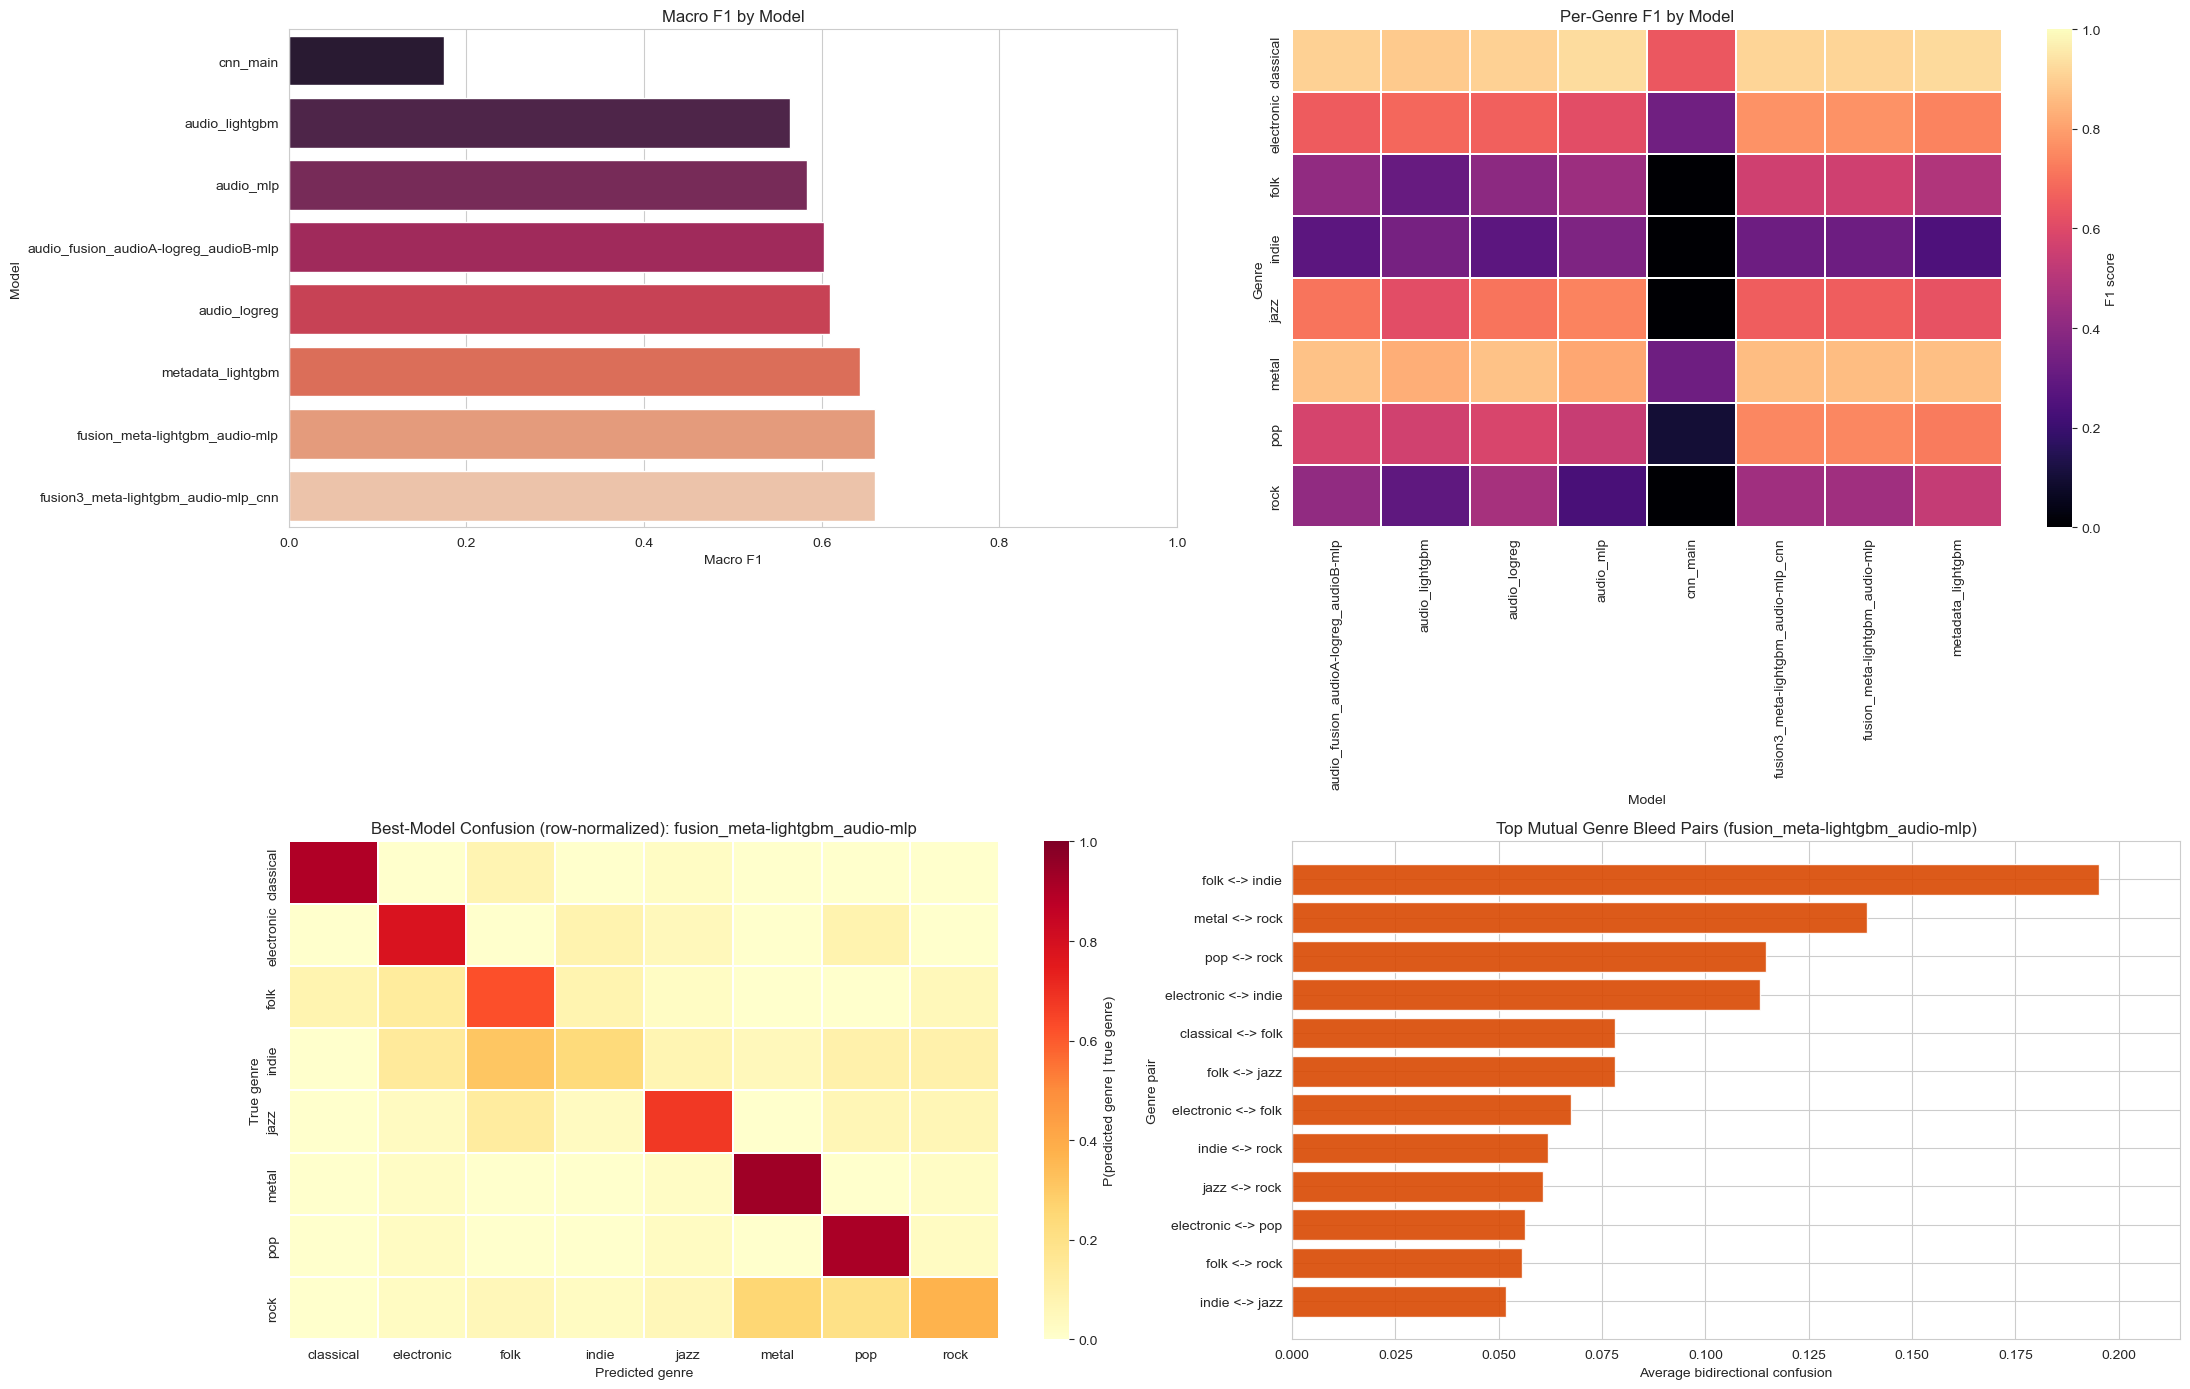

In [70]:
# Visual summary: model scores, per-genre F1, confusion heatmap, and bleed pairs.
import matplotlib.pyplot as plt
import seaborn as sns

required_vars = [
    'SUMMARY_MODEL_TABLE', 'SUMMARY_GENRE_F1_TABLE', 'SUMMARY_BEST_MODEL',
    'SUMMARY_BEST_CM', 'SUMMARY_BLEED_MUTUAL', 'SUMMARY_LABELS'
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError('Run the previous Step 11 cell first. Missing: ' + ', '.join(missing))

plot_models = SUMMARY_MODEL_TABLE.sort_values('macro_f1', ascending=True)
cm_df = pd.DataFrame(SUMMARY_BEST_CM, index=SUMMARY_LABELS, columns=SUMMARY_LABELS)
bleed_plot = SUMMARY_BLEED_MUTUAL.head(min(12, len(SUMMARY_BLEED_MUTUAL))).copy()
bleed_plot = bleed_plot.sort_values('mutual_bleed', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

sns.barplot(
    data=plot_models,
    x='macro_f1',
    y='model',
    palette='rocket',
    ax=axes[0, 0],
)
axes[0, 0].set_title('Macro F1 by Model')
axes[0, 0].set_xlabel('Macro F1')
axes[0, 0].set_ylabel('Model')
axes[0, 0].set_xlim(0, 1)

sns.heatmap(
    SUMMARY_GENRE_F1_TABLE.fillna(0.0),
    cmap='magma',
    vmin=0,
    vmax=1,
    linewidths=0.25,
    ax=axes[0, 1],
    cbar_kws={'label': 'F1 score'},
)
axes[0, 1].set_title('Per-Genre F1 by Model')
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Genre')

sns.heatmap(
    cm_df,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.25,
    ax=axes[1, 0],
    cbar_kws={'label': 'P(predicted genre | true genre)'},
)
axes[1, 0].set_title(f'Best-Model Confusion (row-normalized): {SUMMARY_BEST_MODEL}')
axes[1, 0].set_xlabel('Predicted genre')
axes[1, 0].set_ylabel('True genre')

if len(bleed_plot) > 0:
    labels = bleed_plot['genre_a'] + ' <-> ' + bleed_plot['genre_b']
    axes[1, 1].barh(labels, bleed_plot['mutual_bleed'], color='#d94801', alpha=0.9)
    axes[1, 1].set_xlim(0, max(0.05, float(bleed_plot['mutual_bleed'].max()) * 1.1))
    axes[1, 1].set_title(f'Top Mutual Genre Bleed Pairs ({SUMMARY_BEST_MODEL})')
    axes[1, 1].set_xlabel('Average bidirectional confusion')
    axes[1, 1].set_ylabel('Genre pair')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [71]:
# Auto-generated narrative summary for report/discussion sections.
from IPython.display import Markdown, display

required_vars = [
    'SUMMARY_MODEL_TABLE', 'SUMMARY_BEST_MODEL', 'SUMMARY_BLEED_MUTUAL',
    'SUMMARY_GENRE_DIAGNOSTICS', 'SUMMARY_DATASET_STATS', 'SUMMARY_SPLIT'
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError('Run the Step 11 analysis cell first. Missing: ' + ', '.join(missing))

summary_by_model = SUMMARY_MODEL_TABLE.set_index('model')
best_row = SUMMARY_MODEL_TABLE.iloc[0]
best_model = str(best_row['model'])
best_macro_f1 = float(best_row['macro_f1'])
best_acc = float(best_row['accuracy'])
best_n = int(best_row['n_eval'])

meta_tag = None
if 'METADATA_CLASSIFIER' in globals():
    candidate = f'metadata_{METADATA_CLASSIFIER}'
    if candidate in summary_by_model.index:
        meta_tag = candidate

audio_tag = 'audio_mlp' if 'audio_mlp' in summary_by_model.index else None
if audio_tag is None and 'AUDIO_CLASSIFIER' in globals():
    candidate = f'audio_{AUDIO_CLASSIFIER}'
    if candidate in summary_by_model.index:
        audio_tag = candidate

equivalence_line = 'Could not directly compare metadata vs audio MLP in this run.'
if meta_tag and audio_tag:
    meta_f1 = float(summary_by_model.loc[meta_tag, 'macro_f1'])
    audio_f1 = float(summary_by_model.loc[audio_tag, 'macro_f1'])
    delta = abs(meta_f1 - audio_f1)
    relation = 'roughly equivalent' if delta <= 0.03 else 'materially different'
    equivalence_line = (
        f'Metadata model `{meta_tag}` ({meta_f1:.3f}) and audio model `{audio_tag}` ({audio_f1:.3f}) '
        f'are {relation} on macro-F1 (delta={delta:.3f}).'
    )

top_bleed = SUMMARY_BLEED_MUTUAL.head(5)
if len(top_bleed) > 0:
    bleed_text = '; '.join(
        f'{row.genre_a}<->{row.genre_b} ({row.mutual_bleed:.2f})'
        for row in top_bleed.itertuples(index=False)
    )
else:
    bleed_text = 'No reliable bleed pairs were available.'

hardest = SUMMARY_GENRE_DIAGNOSTICS.head(min(3, len(SUMMARY_GENRE_DIAGNOSTICS)))
if len(hardest) > 0:
    hardest_text = '; '.join(
        f'{idx} (acc={row.accuracy:.2f}, margin={row.mean_margin:.2f})'
        for idx, row in hardest.iterrows()
    )
else:
    hardest_text = 'No genre diagnostics available.'

artist_overlap = SUMMARY_DATASET_STATS.get('artist_overlap_fraction_vs_train', np.nan)
if np.isnan(artist_overlap):
    realism_line = (
        'Artist overlap between train and evaluation could not be computed. '
        'For stricter realism, use artist-disjoint splits.'
    )
else:
    realism_line = (
        f'Artist overlap between train and {SUMMARY_SPLIT} is {artist_overlap:.1%}. '
        'Higher overlap usually makes classification easier.'
    )

imbalance = float(SUMMARY_DATASET_STATS.get('class_balance_ratio_max_over_min', np.nan))
if np.isfinite(imbalance):
    imbalance_line = f'Class imbalance ratio (max/min support) is {imbalance:.2f}.'
else:
    imbalance_line = 'Class imbalance ratio was not available.'

summary_md = (
    f"### Discussion Summary ({SUMMARY_SPLIT.upper()} split)\n\n"
    f"- Best overall model: `{best_model}` with macro-F1 {best_macro_f1:.3f}, accuracy {best_acc:.3f}, n={best_n}.\n"
    f"- Metadata vs audio MLP: {equivalence_line}\n"
    f"- Strongest genre-overlap pairs: {bleed_text}.\n"
    f"- Hardest genres in this run: {hardest_text}.\n"
    f"- Dataset realism check: {realism_line}\n"
    f"- Dataset balance check: {imbalance_line}\n\n"
    "### Implications\n\n"
    "- Genre should be interpreted probabilistically, not only as hard labels.\n"
    "- Overlap-heavy genre pairs benefit from fusion and calibrated probabilities.\n"
    "- More realistic test design (artist-disjoint, harder OOD tracks) improves trustworthiness of reported metrics.\n"
)

display(Markdown(summary_md))

### Discussion Summary (TEST split)

- Best overall model: `fusion_meta-lightgbm_audio-mlp` with macro-F1 0.660, accuracy 0.690, n=326.
- Metadata vs audio MLP: Metadata model `metadata_lightgbm` (0.643) and audio model `audio_mlp` (0.584) are materially different on macro-F1 (delta=0.059).
- Strongest genre-overlap pairs: folk<->indie (0.20); metal<->rock (0.14); pop<->rock (0.11); electronic<->indie (0.11); classical<->folk (0.08).
- Hardest genres in this run: indie (acc=0.24, margin=0.22); rock (acc=0.37, margin=0.21); folk (acc=0.62, margin=0.21).
- Dataset realism check: Artist overlap between train and test is 0.0%. Higher overlap usually makes classification easier.
- Dataset balance check: Class imbalance ratio (max/min support) is 1.94.

### Implications

- Genre should be interpreted probabilistically, not only as hard labels.
- Overlap-heavy genre pairs benefit from fusion and calibrated probabilities.
- More realistic test design (artist-disjoint, harder OOD tracks) improves trustworthiness of reported metrics.


In [72]:
# In-line artefact checklist (moved here so outputs and conclusions stay together).
from pathlib import Path

required_vars = ['PROJECT_ROOT', 'MODEL_DIR', 'SPLITS_DIR']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError('Run Configuration first. Missing: ' + ', '.join(missing))

artefact_rows = [
    ('metadata_csv', PROJECT_ROOT / 'data' / 'processed' / 'metadata.csv'),
    ('split_train', SPLITS_DIR / 'train.csv'),
    ('split_val', SPLITS_DIR / 'val.csv'),
    ('split_test', SPLITS_DIR / 'test.csv'),
    ('processed_audio_dir', PROJECT_ROOT / 'data' / 'processed' / 'audio'),
    ('handcrafted_audio_features', PROJECT_ROOT / 'data' / 'processed' / 'features' / 'handcrafted_audio_features.csv'),
    ('extra_audio_metadata', PROJECT_ROOT / 'data' / 'processed' / 'extra_audio_metadata.csv'),
    ('audio_aug_splits_dir', PROJECT_ROOT / 'data' / 'splits' / 'audio_augmented'),
    ('selected_embeddings_npz', Path(SELECTED_EMBEDDINGS_NPZ)),
    ('label_encoder', MODEL_DIR / 'label_encoder.joblib'),
    ('metadata_model', MODEL_DIR / f'metadata_{METADATA_CLASSIFIER}.joblib' if 'METADATA_CLASSIFIER' in globals() else MODEL_DIR / 'metadata_lightgbm.joblib'),
    ('audio_model', MODEL_DIR / f'audio_{AUDIO_CLASSIFIER}.joblib' if 'AUDIO_CLASSIFIER' in globals() else MODEL_DIR / 'audio_mlp.joblib'),
    ('audio_preprocessor', MODEL_DIR / f'audio_preprocessor_{AUDIO_CLASSIFIER}.joblib' if 'AUDIO_CLASSIFIER' in globals() else MODEL_DIR / 'audio_preprocessor_mlp.joblib'),
    ('fusion_weights', MODEL_DIR / f'fusion_weights_meta-{FUSION_META_CLASSIFIER}_audio-{FUSION_AUDIO_CLASSIFIER}.joblib' if 'FUSION_META_CLASSIFIER' in globals() and 'FUSION_AUDIO_CLASSIFIER' in globals() else MODEL_DIR / 'fusion_weights_meta-lightgbm_audio-mlp.joblib'),
    ('fusion_confusion_png', MODEL_DIR / f'confusion_fusion_meta-{FUSION_META_CLASSIFIER}_audio-{FUSION_AUDIO_CLASSIFIER}.png' if 'FUSION_META_CLASSIFIER' in globals() and 'FUSION_AUDIO_CLASSIFIER' in globals() else MODEL_DIR / 'confusion_fusion_meta-lightgbm_audio-mlp.png'),
    ('audio_fusion_weights', MODEL_DIR / f'audio_fusion_weights_audioA-{AUDIO_FUSION_CLASSIFIER_A}_audioB-{AUDIO_FUSION_CLASSIFIER_B}.joblib' if 'AUDIO_FUSION_CLASSIFIER_A' in globals() and 'AUDIO_FUSION_CLASSIFIER_B' in globals() else MODEL_DIR / 'audio_fusion_weights_audioA-logreg_audioB-mlp.joblib'),
    ('cnn_main_dir', globals().get('CNN_MAIN_DIR', MODEL_DIR / 'cnn_main')),
    ('cnn_eval_test_json', (globals().get('CNN_MAIN_DIR', MODEL_DIR / 'cnn_main')) / 'eval' / 'report_test.json'),
    ('fusion3_weights', MODEL_DIR / f'fusion3_weights_meta-{FUSION_META_CLASSIFIER}_audio-{FUSION_AUDIO_CLASSIFIER}_cnn.joblib' if 'FUSION_META_CLASSIFIER' in globals() and 'FUSION_AUDIO_CLASSIFIER' in globals() else MODEL_DIR / 'fusion3_weights_meta-lightgbm_audio-mlp_cnn.joblib'),
]

artefact_df = pd.DataFrame([
    {
        'artefact': name,
        'path': str(path),
        'exists': Path(path).exists(),
    }
    for name, path in artefact_rows
]).sort_values(['exists', 'artefact'], ascending=[False, True]).reset_index(drop=True)

print('Artefact checklist (inline):')
display(artefact_df)

Artefact checklist (inline):


,artefact,path,exists
0,audio_aug_splits_dir,/Volumes/MZ Music/genre-classifier/data/split...,True
1,audio_fusion_weights,/Volumes/MZ Music/genre-classifier/models/ful...,True
2,audio_model,/Volumes/MZ Music/genre-classifier/models/ful...,True
3,audio_preprocessor,/Volumes/MZ Music/genre-classifier/models/ful...,True
4,cnn_eval_test_json,/Volumes/MZ Music/genre-classifier/models/ful...,True
5,cnn_main_dir,/Volumes/MZ Music/genre-classifier/models/ful...,True
6,extra_audio_metadata,/Volumes/MZ Music/genre-classifier/data/proce...,True
7,fusion3_weights,/Volumes/MZ Music/genre-classifier/models/ful...,True
8,fusion_confusion_png,/Volumes/MZ Music/genre-classifier/models/ful...,True
9,fusion_weights,/Volumes/MZ Music/genre-classifier/models/ful...,True
